# OpenTelemetry Trace Duration Heatmap Analysis

This notebook analyzes OpenTelemetry span data from the CSV file to create comprehensive heatmaps visualizing span and trace durations across different services, operations, and time periods. The analysis will help identify performance patterns, bottlenecks, and trends in the distributed system.

## 1. Import Required Libraries

Import pandas for data manipulation, matplotlib and seaborn for visualization, numpy for numerical operations, and datetime for time handling.

In [24]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime
import warnings
warnings.filterwarnings('ignore')

# Set plotting style
plt.style.use('default')
sns.set_palette("husl")

# Configure display options
pd.set_option('display.max_columns', None)
pd.set_option('display.width', None)

print("Libraries imported successfully!")

Libraries imported successfully!


## 2. Load and Explore the CSV Data

Load the OpenTelemetry span data from the CSV file using pandas, examine the data structure, and display basic statistics about the dataset.

In [2]:
# Load the CSV data
df = pd.read_csv('data.csv', sep='\t')

print("Dataset shape:", df.shape)
print("\nColumn names:")
print(df.columns.tolist())

# Display first few rows
print("\nFirst 5 rows:")
df.head()

Dataset shape: (1000, 54)

Column names:
['TenantId', 'TimeGenerated [UTC]', 'Name', 'SpanId', 'ParentSpanId', 'TraceId', 'TraceState', 'Kind', 'EndTime [UTC]', 'StatusMessage', 'StatusCode', 'Links', 'ScopeName', 'ScopeVersion', 'ResourceAttributes', 'DroppedAttributesCount', 'DroppedEventsCount', 'DroppedLinksCount', 'Attributes', 'ServiceNamespace', 'ServiceName', 'ServiceVersion', 'ServiceInstanceId', 'RoleName', 'SDKVersion', 'EndUserId', 'ResourceAttributesId', 'DurationMs', 'ResultCode', 'UserId', 'UserAccountId', 'SessionId', 'ClientBrowser', 'ClientOS', 'ClientModel', 'ClientType', 'ClientIP', 'ClientCity', 'ClientStateOrProvince', 'ClientCountryOrRegion', 'Measurements', 'SyntheticSource', 'Source', 'Target', 'EnrichedName', 'OperationName', 'Success', 'DependencyType', 'Data', 'ItemCount', 'PerformanceBucket', 'SourceSystem', 'Type', '_ResourceId']

First 5 rows:


,TenantId,TimeGenerated [UTC],Name,SpanId,ParentSpanId,TraceId,TraceState,Kind,EndTime [UTC],StatusMessage,StatusCode,Links,ScopeName,ScopeVersion,ResourceAttributes,DroppedAttributesCount,DroppedEventsCount,DroppedLinksCount,Attributes,ServiceNamespace,ServiceName,ServiceVersion,ServiceInstanceId,RoleName,SDKVersion,EndUserId,ResourceAttributesId,DurationMs,ResultCode,UserId,UserAccountId,SessionId,ClientBrowser,ClientOS,ClientModel,ClientType,ClientIP,ClientCity,ClientStateOrProvince,ClientCountryOrRegion,Measurements,SyntheticSource,Source,Target,EnrichedName,OperationName,Success,DependencyType,Data,ItemCount,PerformanceBucket,SourceSystem,Type,_ResourceId
0,4f42970f-23c5-4a26-ba64-f40c3775fdfe,"9/15/2025, 4:14:39.092 PM",/msdemo.RecommendationService/ListRecommendations,9a4452baf3edc1a9,a63ba12134955e1e,6e36806dfb30f7c5f53098e309706cf7,NaN,Server,"9/15/2025, 4:14:39.194 PM",NaN,NaN,[],opentelemetry.instrumentation.grpc,0.45b0,NaN,0,0,0,"{""rpc.system"":""grpc"",""rpc.grpc.status_code"":0,...",NaN,recommendation,0.1,NaN,recommendation,otlp:unknown:unknown:unknown,NaN,1ceff8fb-924f-11f0-8703-6045bd740685,102617.344,NaN,NaN,NaN,NaN,NaN,NaN,NaN,PC,0.0.0.0,NaN,NaN,NaN,{},NaN,NaN,msdemo.RecommendationService,/msdemo.RecommendationService/ListRecommendations,NaN,True,NaN,ListRecommendations,1,1min-2min,NaN,OTelSpans,/subscriptions/b9842c7c-1a38-4385-8f39-a513147...
1,4f42970f-23c5-4a26-ba64-f40c3775fdfe,"9/15/2025, 4:14:41.533 PM",/msdemo.ProductCatalogService/ListProducts,df79fdfb897e6eea,70bd82799c8265ba,a80bfee022361826b1425ff0e454a89e,NaN,Client,"9/15/2025, 4:14:41.561 PM",NaN,NaN,[],opentelemetry.instrumentation.grpc,0.45b0,NaN,0,0,0,"{""rpc.system"":""grpc"",""rpc.grpc.status_code"":0,...",NaN,recommendation,0.1,NaN,recommendation,otlp:unknown:unknown:unknown,NaN,1ceff8fb-924f-11f0-8703-6045bd740685,28650.240,NaN,NaN,NaN,NaN,NaN,NaN,NaN,PC,0.0.0.0,NaN,NaN,NaN,{},NaN,NaN,msdemo.ProductCatalogService,/msdemo.ProductCatalogService/ListProducts,NaN,True,grpc,ListProducts,1,15sec-30sec,NaN,OTelSpans,/subscriptions/b9842c7c-1a38-4385-8f39-a513147...
2,4f42970f-23c5-4a26-ba64-f40c3775fdfe,"9/15/2025, 4:14:41.424 PM",/msdemo.RecommendationService/ListRecommendations,9ed35ee047470e38,741a4ae8a82b771e,a80bfee022361826b1425ff0e454a89e,NaN,Server,"9/15/2025, 4:14:41.562 PM",NaN,NaN,[],opentelemetry.instrumentation.grpc,0.45b0,NaN,0,0,0,"{""rpc.system"":""grpc"",""rpc.grpc.status_code"":0,...",NaN,recommendation,0.1,NaN,recommendation,otlp:unknown:unknown:unknown,NaN,1ceff8fb-924f-11f0-8703-6045bd740685,138162.944,NaN,NaN,NaN,NaN,NaN,NaN,NaN,PC,0.0.0.0,NaN,NaN,NaN,{},NaN,NaN,msdemo.RecommendationService,/msdemo.RecommendationService/ListRecommendations,NaN,True,NaN,ListRecommendations,1,2min-5min,NaN,OTelSpans,/subscriptions/b9842c7c-1a38-4385-8f39-a513147...
3,4f42970f-23c5-4a26-ba64-f40c3775fdfe,"9/15/2025, 4:14:41.972 PM",/msdemo.ProductCatalogService/ListProducts,bfff1a854f65afd3,51cc77dacd241c0f,135ad91c268fd85f5b9247d33571a7d2,NaN,Client,"9/15/2025, 4:14:41.990 PM",NaN,NaN,[],opentelemetry.instrumentation.grpc,0.45b0,NaN,0,0,0,"{""rpc.system"":""grpc"",""rpc.grpc.status_code"":0,...",NaN,recommendation,0.1,NaN,recommendation,otlp:unknown:unknown:unknown,NaN,1ceff8fb-924f-11f0-8703-6045bd740685,17715.968,NaN,NaN,NaN,NaN,NaN,NaN,NaN,PC,0.0.0.0,NaN,NaN,NaN,{},NaN,NaN,msdemo.ProductCatalogService,/msdemo.ProductCatalogService/ListProducts,NaN,True,grpc,ListProducts,1,15sec-30sec,NaN,OTelSpans,/subscriptions/b9842c7c-1a38-4385-8f39-a513147...
4,4f42970f-23c5-4a26-ba64-f40c3775fdfe,"9/15/2025, 4:14:41.856 PM",/msdemo.RecommendationService/ListRecommendations,298cd1444fdb7139,62d125419c88f78f,135ad91c268fd85f5b9247d33571a7d2,NaN,Server,"9/15/2025, 4:14:41.991 PM",NaN,NaN,[],opentelemetry.instrumentation.grpc,0.45b0,NaN,0,0,0,"{""rpc.system"":""grpc"",""rpc.grpc.status_code"":0,...",NaN,recommendation,0.1,NaN,recommendation,otlp:unknown:unknown:unknown,NaN,1ceff8fb-924f-11f0-8703-6045bd740685,134374.400,NaN,NaN,NaN,NaN,NaN,NaN,NaN,PC,0.0

In [3]:
# Examine data types and missing values
print("Data Info:")
print(df.info())

print("\nKey columns for analysis:")
key_columns = ['Name', 'ServiceName', 'TraceId', 'SpanId', 'ParentSpanId', 'DurationMs', 'TimeGenerated [UTC]', 'Kind']
for col in key_columns:
    if col in df.columns:
        print(f"- {col}: {df[col].dtype}, Missing: {df[col].isnull().sum()}")

# Basic statistics for duration
print(f"\nDuration statistics (in ms):")
print(df['DurationMs'].describe())

Data Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 54 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   TenantId                1000 non-null   object 
 1   TimeGenerated [UTC]     1000 non-null   object 
 2   Name                    1000 non-null   object 
 3   SpanId                  1000 non-null   object 
 4   ParentSpanId            950 non-null    object 
 5   TraceId                 1000 non-null   object 
 6   TraceState              0 non-null      float64
 7   Kind                    1000 non-null   object 
 8   EndTime [UTC]           1000 non-null   object 
 9   StatusMessage           5 non-null      object 
 10  StatusCode              7 non-null      object 
 11  Links                   1000 non-null   object 
 12  ScopeName               978 non-null    object 
 13  ScopeVersion            878 non-null    object 
 14  ResourceAttributes      0 non-

## 3. Data Preprocessing and Cleaning

Clean the data by handling missing values, convert timestamp columns to datetime objects, extract service names and operation names, and convert duration from milliseconds to appropriate units.

In [4]:
# Clean and preprocess the data
df_clean = df.copy()

# Convert timestamps to datetime
df_clean['timestamp'] = pd.to_datetime(df_clean['TimeGenerated [UTC]'])

# Convert duration to seconds for better readability
df_clean['duration_seconds'] = df_clean['DurationMs'] / 1000

# Extract operation name from Name field (remove service prefix if present)
df_clean['operation'] = df_clean['Name'].str.split('/').str[-1]

# Clean service names - use ServiceName if available, otherwise extract from Name
df_clean['service'] = df_clean['ServiceName'].fillna(
    df_clean['Name'].str.split('/').str[1].str.split('.').str[1]
)

# Remove rows with missing essential data
df_clean = df_clean.dropna(subset=['TraceId', 'SpanId', 'DurationMs'])

# Add time-based features for temporal analysis
df_clean['hour'] = df_clean['timestamp'].dt.hour
df_clean['minute'] = df_clean['timestamp'].dt.minute
df_clean['time_bucket'] = df_clean['hour'].astype(str) + ':' + (df_clean['minute'] // 15 * 15).astype(str).str.zfill(2)

print(f"Cleaned dataset shape: {df_clean.shape}")
print(f"Unique services: {df_clean['service'].nunique()}")
print(f"Unique operations: {df_clean['operation'].nunique()}")
print(f"Unique traces: {df_clean['TraceId'].nunique()}")

# Display service and operation summary
print("\nService distribution:")
print(df_clean['service'].value_counts().head(10))

Cleaned dataset shape: (1000, 61)
Unique services: 10
Unique operations: 35
Unique traces: 85

Service distribution:
service
frontend          408
productcatalog    179
cart               93
currency           77
recommendation     76
checkout           70
shipping           41
adservice          32
payment            14
email              10
Name: count, dtype: int64


## 4. Calculate Trace Durations

Group spans by TraceId to calculate total trace durations, identify root spans, and compute span hierarchies for comprehensive duration analysis.

In [5]:
# Calculate trace-level statistics
trace_stats = df_clean.groupby('TraceId').agg({
    'duration_seconds': ['min', 'max', 'mean', 'sum', 'count'],
    'timestamp': ['min', 'max'],
    'service': lambda x: list(x.unique())
}).round(3)

# Flatten column names
trace_stats.columns = ['_'.join(col).strip() for col in trace_stats.columns]
trace_stats['trace_duration'] = (
    pd.to_datetime(trace_stats['timestamp_max']) - 
    pd.to_datetime(trace_stats['timestamp_min'])
).dt.total_seconds()

# Identify root spans (spans without parent in the same trace)
def find_root_spans(group):
    parent_spans = set(group['ParentSpanId'].dropna())
    all_spans = set(group['SpanId'])
    root_spans = all_spans - parent_spans
    return group[group['SpanId'].isin(root_spans)]

root_spans = df_clean.groupby('TraceId').apply(find_root_spans).reset_index(drop=True)

print(f"Total traces: {len(trace_stats)}")
print(f"Root spans found: {len(root_spans)}")
print(f"\nTrace duration statistics (seconds):")
print(trace_stats['trace_duration'].describe())

# Display sample trace analysis
print(f"\nSample trace breakdown:")
sample_trace = df_clean['TraceId'].iloc[0]
sample_spans = df_clean[df_clean['TraceId'] == sample_trace][['service', 'operation', 'duration_seconds', 'Kind']]
print(sample_spans.head(10))

Total traces: 85
Root spans found: 573

Trace duration statistics (seconds):
count    85.000000
mean      0.643412
std       2.780062
min       0.000000
25%       0.014000
50%       0.286000
75%       0.420000
max      24.853000
Name: trace_duration, dtype: float64

Sample trace breakdown:
           service                       operation  duration_seconds      Kind
0   recommendation             ListRecommendations        102.617344    Server
6   productcatalog                    ListProducts         13.277952    Server
7   productcatalog                      GetProduct          8.225280    Server
8   productcatalog                      GetProduct         15.227904    Server
9   productcatalog                      GetProduct         14.236160    Server
10  productcatalog                      GetProduct         11.249920    Server
11  productcatalog                      GetProduct         16.185856    Server
12  productcatalog                      GetProduct         17.250816    Serve

## 5. Create Duration Heatmap by Service and Operation

Generate a heatmap showing duration patterns across different services and operations using seaborn, with proper color scaling and annotations.

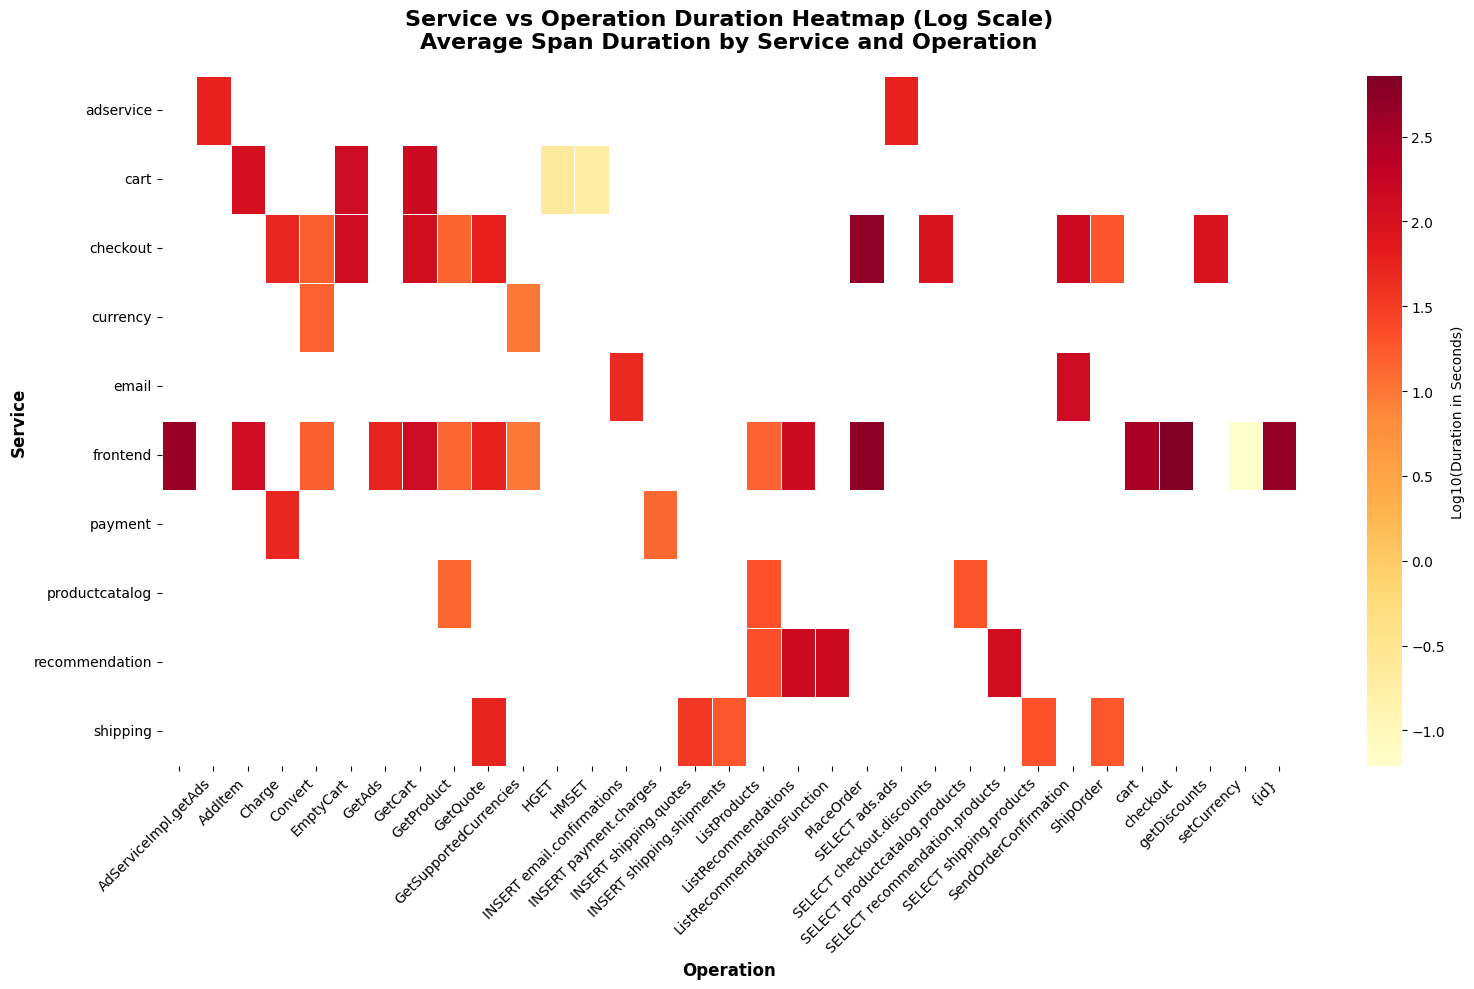

Services included: 10
Operations included: 33
Service-Operation combinations: 51


In [7]:
# Create a pivot table for service vs operation duration heatmap
pivot_service_operation = df_clean.groupby(['service', 'operation'])['duration_seconds'].agg(['mean', 'count']).reset_index()

# Flatten column names for easier access
pivot_service_operation.columns = ['service', 'operation', 'mean_duration', 'count']

# Filter out combinations with very few samples for cleaner visualization
min_samples = 3
pivot_filtered = pivot_service_operation[pivot_service_operation['count'] >= min_samples]

# Create the pivot table for heatmap
heatmap_data = pivot_filtered.pivot(index='service', columns='operation', values='mean_duration')

# Create the heatmap
plt.figure(figsize=(16, 10))
mask = heatmap_data.isnull()

# Use log scale for better visualization of wide duration ranges
heatmap_data_log = np.log10(heatmap_data + 0.001)  # Add small value to handle zeros

sns.heatmap(
    heatmap_data_log,
    mask=mask,
    annot=False,
    cmap='YlOrRd',
    cbar_kws={'label': 'Log10(Duration in Seconds)'},
    linewidths=0.5,
    linecolor='white'
)

plt.title('Service vs Operation Duration Heatmap (Log Scale)\nAverage Span Duration by Service and Operation', 
          fontsize=16, fontweight='bold', pad=20)
plt.xlabel('Operation', fontsize=12, fontweight='bold')
plt.ylabel('Service', fontsize=12, fontweight='bold')
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

# Display summary statistics
print(f"Services included: {len(heatmap_data.index)}")
print(f"Operations included: {len(heatmap_data.columns)}")
print(f"Service-Operation combinations: {(~mask).sum().sum()}")

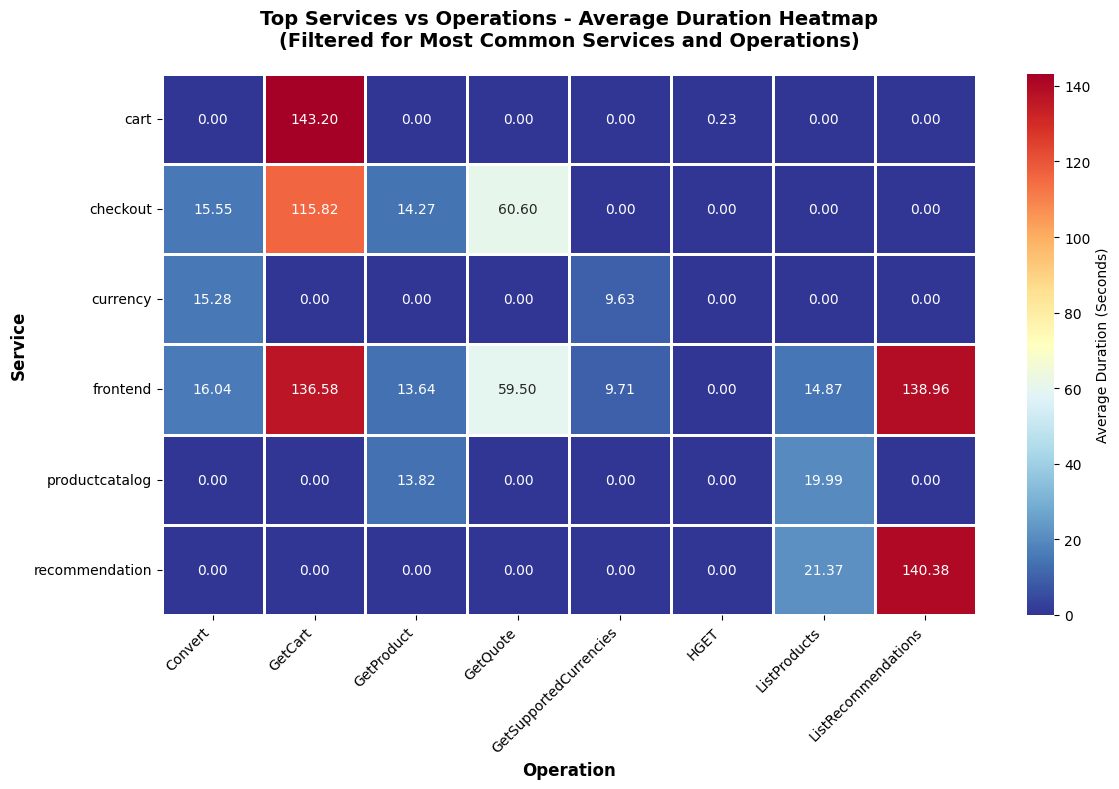

In [8]:
# Create a simplified heatmap with top operations and services
top_services = df_clean['service'].value_counts().head(6).index
top_operations = df_clean['operation'].value_counts().head(8).index

df_top = df_clean[
    (df_clean['service'].isin(top_services)) & 
    (df_clean['operation'].isin(top_operations))
]

# Create pivot for top services and operations
pivot_top = df_top.groupby(['service', 'operation'])['duration_seconds'].mean().unstack(fill_value=0)

plt.figure(figsize=(12, 8))
sns.heatmap(
    pivot_top,
    annot=True,
    fmt='.2f',
    cmap='RdYlBu_r',
    cbar_kws={'label': 'Average Duration (Seconds)'},
    linewidths=1,
    linecolor='white'
)

plt.title('Top Services vs Operations - Average Duration Heatmap\n(Filtered for Most Common Services and Operations)', 
          fontsize=14, fontweight='bold', pad=20)
plt.xlabel('Operation', fontsize=12, fontweight='bold')
plt.ylabel('Service', fontsize=12, fontweight='bold')
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

## 6. Create Time-based Duration Heatmap

Create heatmaps that show duration patterns over time intervals (hourly, by minute) to identify performance trends and anomalies.

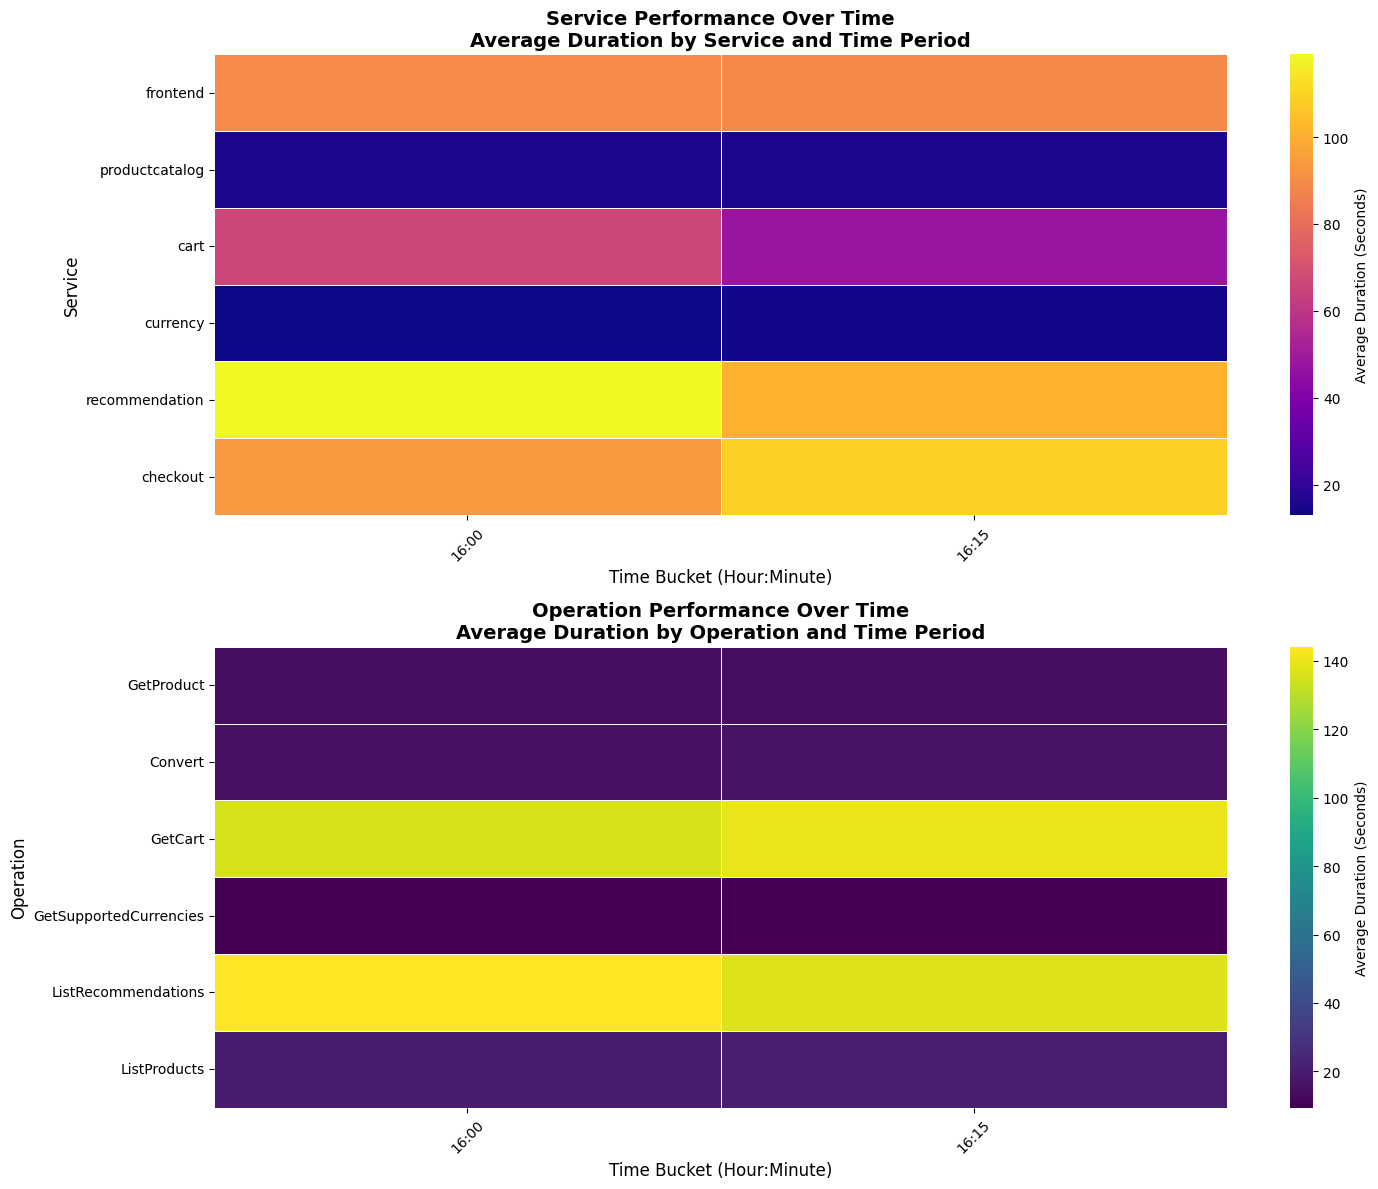

Time-based analysis:
Time range: 2025-09-15 16:14:38.046000 to 2025-09-15 16:15:52.079000
Unique time buckets: 2
Average spans per time bucket: 500.0


In [9]:
# Create time-based heatmaps
fig, axes = plt.subplots(2, 1, figsize=(15, 12))

# 1. Service vs Time Bucket Heatmap
time_service_pivot = df_clean.groupby(['time_bucket', 'service'])['duration_seconds'].mean().unstack(fill_value=0)

# Select top services for clarity
top_services_time = df_clean['service'].value_counts().head(6).index
time_service_filtered = time_service_pivot[top_services_time]

sns.heatmap(
    time_service_filtered.T,
    ax=axes[0],
    cmap='plasma',
    cbar_kws={'label': 'Average Duration (Seconds)'},
    linewidths=0.5
)
axes[0].set_title('Service Performance Over Time\nAverage Duration by Service and Time Period', 
                  fontsize=14, fontweight='bold')
axes[0].set_xlabel('Time Bucket (Hour:Minute)', fontsize=12)
axes[0].set_ylabel('Service', fontsize=12)
axes[0].tick_params(axis='x', rotation=45)

# 2. Operation vs Time Bucket Heatmap
time_operation_pivot = df_clean.groupby(['time_bucket', 'operation'])['duration_seconds'].mean().unstack(fill_value=0)

# Select top operations for clarity
top_operations_time = df_clean['operation'].value_counts().head(6).index
time_operation_filtered = time_operation_pivot[top_operations_time]

sns.heatmap(
    time_operation_filtered.T,
    ax=axes[1],
    cmap='viridis',
    cbar_kws={'label': 'Average Duration (Seconds)'},
    linewidths=0.5
)
axes[1].set_title('Operation Performance Over Time\nAverage Duration by Operation and Time Period', 
                  fontsize=14, fontweight='bold')
axes[1].set_xlabel('Time Bucket (Hour:Minute)', fontsize=12)
axes[1].set_ylabel('Operation', fontsize=12)
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

# Display time-based statistics
print("Time-based analysis:")
print(f"Time range: {df_clean['timestamp'].min()} to {df_clean['timestamp'].max()}")
print(f"Unique time buckets: {df_clean['time_bucket'].nunique()}")
print(f"Average spans per time bucket: {len(df_clean) / df_clean['time_bucket'].nunique():.1f}")

## 7. Advanced Heatmap Visualizations

Build additional heatmaps including duration distribution by performance buckets, correlation matrices between different services, and comparative analysis of client vs server spans.

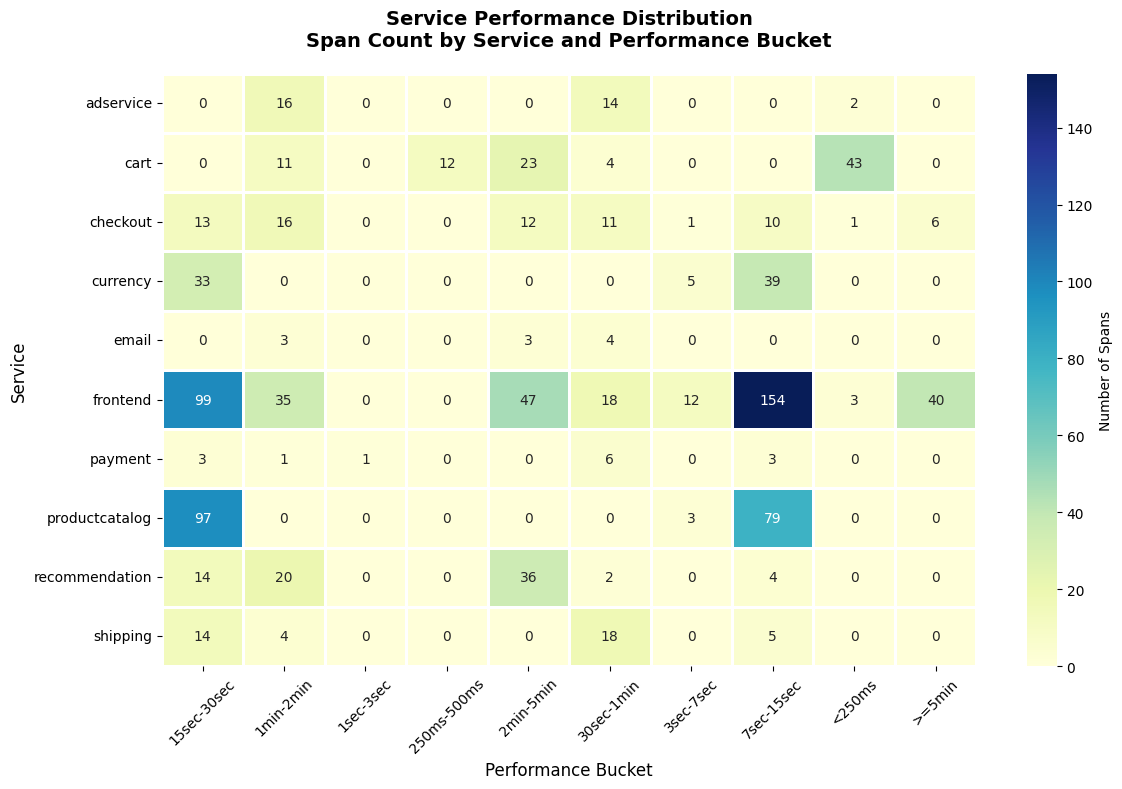

In [10]:
# 1. Performance Bucket Analysis
if 'PerformanceBucket' in df_clean.columns:
    perf_bucket_pivot = df_clean.groupby(['service', 'PerformanceBucket']).size().unstack(fill_value=0)
    
    plt.figure(figsize=(12, 8))
    sns.heatmap(
        perf_bucket_pivot,
        annot=True,
        fmt='d',
        cmap='YlGnBu',
        cbar_kws={'label': 'Number of Spans'},
        linewidths=1
    )
    plt.title('Service Performance Distribution\nSpan Count by Service and Performance Bucket', 
              fontsize=14, fontweight='bold', pad=20)
    plt.xlabel('Performance Bucket', fontsize=12)
    plt.ylabel('Service', fontsize=12)
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()
else:
    print("PerformanceBucket column not available for analysis")

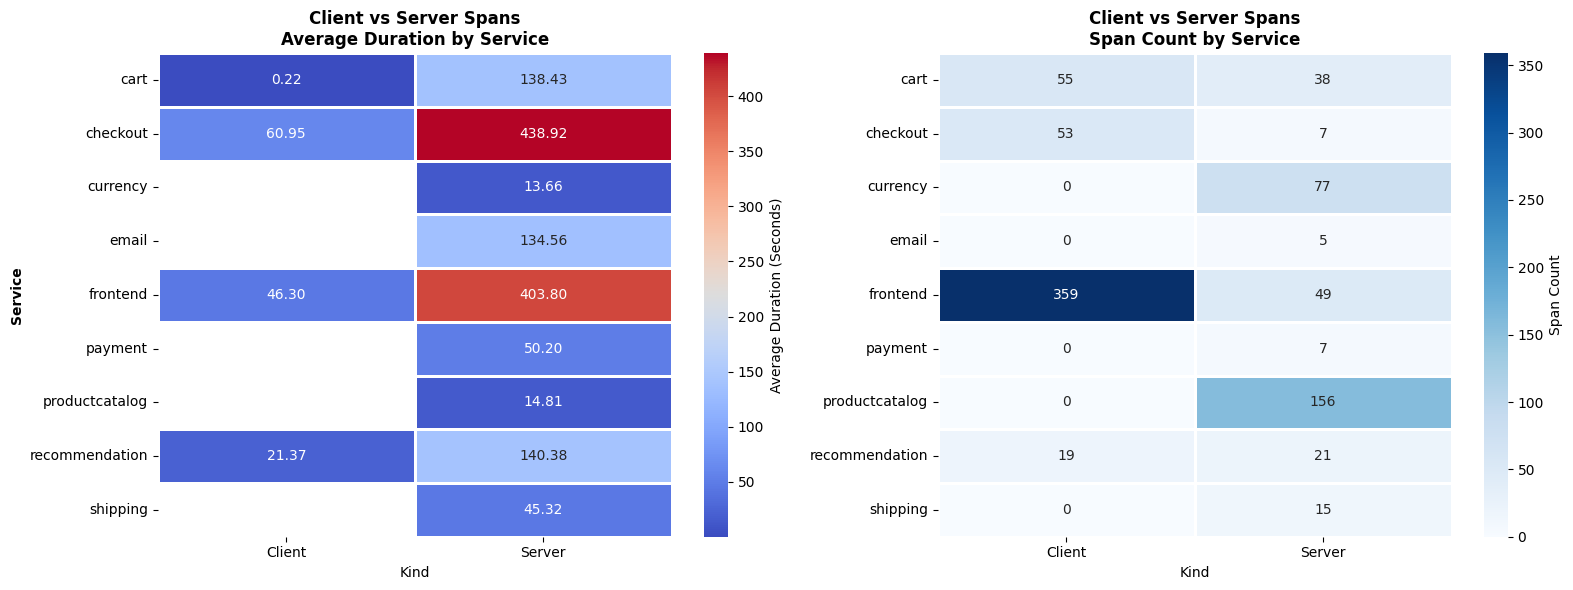

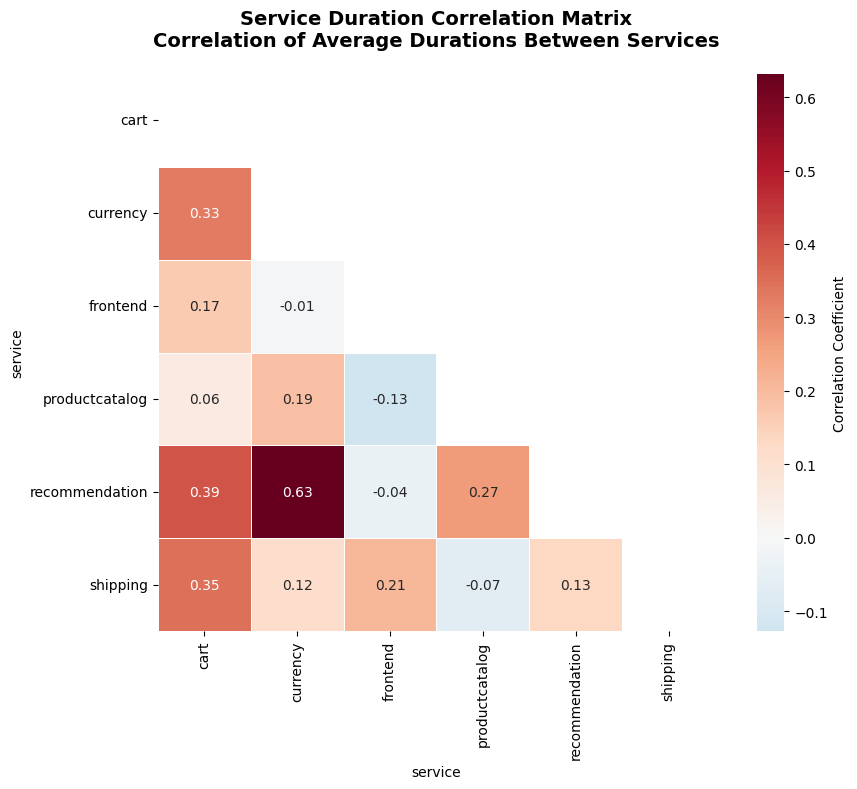

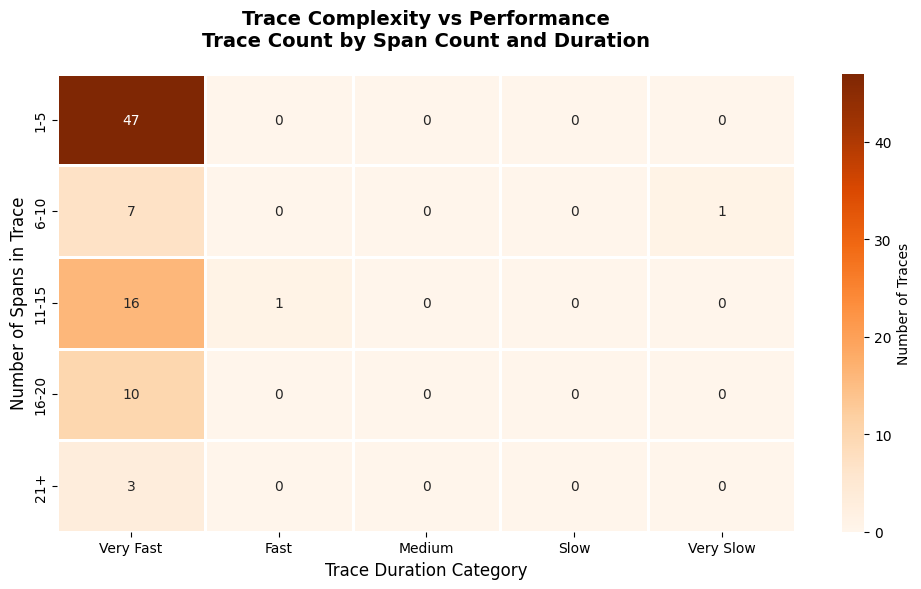

In [14]:
# 2. Client vs Server Span Analysis
if 'Kind' in df_clean.columns:
    client_server_data = df_clean[df_clean['Kind'].isin(['Client', 'Server'])]
    
    if len(client_server_data) > 0:
        pivot_kind = client_server_data.groupby(['service', 'Kind'])['duration_seconds'].agg(['mean', 'count']).reset_index()
        
        # Flatten column names for easier access
        pivot_kind.columns = ['service', 'Kind', 'mean_duration', 'count']
        
        # Convert count to integer
        pivot_kind['count'] = pivot_kind['count'].astype(int)
        
        # Create separate heatmaps for mean duration and count
        fig, axes = plt.subplots(1, 2, figsize=(16, 6))
        
        # Mean duration heatmap
        mean_pivot = pivot_kind.pivot(index='service', columns='Kind', values='mean_duration')
        sns.heatmap(
            mean_pivot,
            ax=axes[0],
            annot=True,
            fmt='.2f',
            cmap='coolwarm',
            cbar_kws={'label': 'Average Duration (Seconds)'},
            linewidths=1
        )
        axes[0].set_title('Client vs Server Spans\nAverage Duration by Service', fontweight='bold')
        axes[0].set_ylabel('Service', fontweight='bold')
        
        # Count heatmap
        count_pivot = pivot_kind.pivot(index='service', columns='Kind', values='count')
        # Ensure all values are integers
        count_pivot = count_pivot.fillna(0).astype(int)
        
        sns.heatmap(
            count_pivot,
            ax=axes[1],
            annot=True,
            fmt='d',
            cmap='Blues',
            cbar_kws={'label': 'Span Count'},
            linewidths=1
        )
        axes[1].set_title('Client vs Server Spans\nSpan Count by Service', fontweight='bold')
        axes[1].set_ylabel('')
        
        plt.tight_layout()
        plt.show()
    else:
        print("No Client or Server spans found in the data")
else:
    print("Kind column not available for Client/Server analysis")

# 3. Service Correlation Matrix
# Create a correlation matrix between service average durations
service_duration_matrix = df_clean.groupby(['TraceId', 'service'])['duration_seconds'].mean().unstack(fill_value=0)

# Calculate correlation only for services with sufficient data
service_counts = (service_duration_matrix > 0).sum()
services_with_data = service_counts[service_counts >= 10].index

if len(services_with_data) > 1:
    correlation_matrix = service_duration_matrix[services_with_data].corr()
    
    plt.figure(figsize=(10, 8))
    mask = np.triu(np.ones_like(correlation_matrix, dtype=bool))
    
    sns.heatmap(
        correlation_matrix,
        mask=mask,
        annot=True,
        fmt='.2f',
        cmap='RdBu_r',
        center=0,
        square=True,
        cbar_kws={'label': 'Correlation Coefficient'},
        linewidths=0.5
    )
    plt.title('Service Duration Correlation Matrix\nCorrelation of Average Durations Between Services', 
              fontsize=14, fontweight='bold', pad=20)
    plt.tight_layout()
    plt.show()
else:
    print("Insufficient data for correlation analysis")

# 4. Trace Duration vs Span Count Heatmap
trace_analysis = trace_stats.copy()
trace_analysis['span_count_bucket'] = pd.cut(
    trace_analysis['duration_seconds_count'], 
    bins=5, 
    labels=['1-5', '6-10', '11-15', '16-20', '21+']
)
trace_analysis['duration_bucket'] = pd.cut(
    trace_analysis['trace_duration'], 
    bins=5, 
    labels=['Very Fast', 'Fast', 'Medium', 'Slow', 'Very Slow']
)

trace_heatmap = trace_analysis.groupby(['span_count_bucket', 'duration_bucket']).size().unstack(fill_value=0)

plt.figure(figsize=(10, 6))
sns.heatmap(
    trace_heatmap,
    annot=True,
    fmt='d',
    cmap='Oranges',
    cbar_kws={'label': 'Number of Traces'},
    linewidths=1
)
plt.title('Trace Complexity vs Performance\nTrace Count by Span Count and Duration', 
          fontsize=14, fontweight='bold', pad=20)
plt.xlabel('Trace Duration Category', fontsize=12)
plt.ylabel('Number of Spans in Trace', fontsize=12)
plt.tight_layout()
plt.show()

In [ ]:
# 3. Service Correlation Matrix
# Create a correlation matrix between service average durations
service_duration_matrix = df_clean.groupby(['TraceId', 'service'])['duration_seconds'].mean().unstack(fill_value=0)

# Calculate correlation only for services with sufficient data
service_counts = (service_duration_matrix > 0).sum()
services_with_data = service_counts[service_counts >= 10].index

if len(services_with_data) > 1:
    correlation_matrix = service_duration_matrix[services_with_data].corr()
    
    plt.figure(figsize=(10, 8))
    mask = np.triu(np.ones_like(correlation_matrix, dtype=bool))
    
    sns.heatmap(
        correlation_matrix,
        mask=mask,
        annot=True,
        fmt='.2f',
        cmap='RdBu_r',
        center=0,
        square=True,
        cbar_kws={'label': 'Correlation Coefficient'},
        linewidths=0.5
    )
    plt.title('Service Duration Correlation Matrix\nCorrelation of Average Durations Between Services', 
              fontsize=14, fontweight='bold', pad=20)
    plt.tight_layout()
    plt.show()
else:
    print("Insufficient data for correlation analysis")

# 4. Trace Duration vs Span Count Heatmap
trace_analysis = trace_stats.copy()
trace_analysis['span_count_bucket'] = pd.cut(
    trace_analysis['duration_seconds_count'], 
    bins=5, 
    labels=['1-5', '6-10', '11-15', '16-20', '21+']
)
trace_analysis['duration_bucket'] = pd.cut(
    trace_analysis['trace_duration'], 
    bins=5, 
    labels=['Very Fast', 'Fast', 'Medium', 'Slow', 'Very Slow']
)

trace_heatmap = trace_analysis.groupby(['span_count_bucket', 'duration_bucket']).size().unstack(fill_value=0)

plt.figure(figsize=(10, 6))
sns.heatmap(
    trace_heatmap,
    annot=True,
    fmt='d',
    cmap='Oranges',
    cbar_kws={'label': 'Number of Traces'},
    linewidths=1
)
plt.title('Trace Complexity vs Performance\nTrace Count by Span Count and Duration', 
          fontsize=14, fontweight='bold', pad=20)
plt.xlabel('Trace Duration Category', fontsize=12)
plt.ylabel('Number of Spans in Trace', fontsize=12)
plt.tight_layout()
plt.show()

## Summary and Key Insights

This analysis provides comprehensive heatmap visualizations of OpenTelemetry trace and span durations. The heatmaps reveal:

In [15]:
# Generate summary insights
print("=== TRACE ANALYSIS SUMMARY ===\n")

print("📊 Dataset Overview:")
print(f"   • Total spans analyzed: {len(df_clean):,}")
print(f"   • Unique traces: {df_clean['TraceId'].nunique():,}")
print(f"   • Unique services: {df_clean['service'].nunique()}")
print(f"   • Unique operations: {df_clean['operation'].nunique()}")
print(f"   • Time range: {(df_clean['timestamp'].max() - df_clean['timestamp'].min()).total_seconds():.0f} seconds")

print(f"\n⏱️  Duration Statistics:")
print(f"   • Fastest span: {df_clean['duration_seconds'].min():.3f} seconds")
print(f"   • Slowest span: {df_clean['duration_seconds'].max():.3f} seconds")
print(f"   • Average span duration: {df_clean['duration_seconds'].mean():.3f} seconds")
print(f"   • Median span duration: {df_clean['duration_seconds'].median():.3f} seconds")

print(f"\n🏗️  Service Performance (Top 5 by average duration):")
service_perf = df_clean.groupby('service')['duration_seconds'].agg(['mean', 'count']).sort_values('mean', ascending=False)
for idx, (service, row) in enumerate(service_perf.head(5).iterrows()):
    print(f"   {idx+1}. {service}: {row['mean']:.3f}s avg ({row['count']} spans)")

print(f"\n🔧 Operation Performance (Top 5 by average duration):")
operation_perf = df_clean.groupby('operation')['duration_seconds'].agg(['mean', 'count']).sort_values('mean', ascending=False)
for idx, (operation, row) in enumerate(operation_perf.head(5).iterrows()):
    print(f"   {idx+1}. {operation}: {row['mean']:.3f}s avg ({row['count']} spans)")

print(f"\n🕒 Time-based Insights:")
hourly_stats = df_clean.groupby('hour')['duration_seconds'].mean().sort_values(ascending=False)
print(f"   • Slowest hour: {hourly_stats.index[0]:02d}:00 ({hourly_stats.iloc[0]:.3f}s avg)")
print(f"   • Fastest hour: {hourly_stats.index[-1]:02d}:00 ({hourly_stats.iloc[-1]:.3f}s avg)")

if 'Kind' in df_clean.columns:
    print(f"\n📡 Span Types:")
    kind_stats = df_clean.groupby('Kind')['duration_seconds'].agg(['mean', 'count'])
    for kind, row in kind_stats.iterrows():
        print(f"   • {kind}: {row['mean']:.3f}s avg ({row['count']} spans)")

print(f"\n✅ Analysis complete! All heatmaps generated successfully.")
print(f"   Use these visualizations to identify performance bottlenecks,")
print(f"   temporal patterns, and service dependencies in your system.")

=== TRACE ANALYSIS SUMMARY ===

📊 Dataset Overview:
   • Total spans analyzed: 1,000
   • Unique traces: 85
   • Unique services: 10
   • Unique operations: 35
   • Time range: 74 seconds

⏱️  Duration Statistics:
   • Fastest span: 0.028 seconds
   • Slowest span: 826.102 seconds
   • Average span duration: 65.344 seconds
   • Median span duration: 18.132 seconds

🏗️  Service Performance (Top 5 by average duration):
   1. recommendation: 106.947s avg (76.0 spans)
   2. checkout: 103.302s avg (70.0 spans)
   3. email: 91.532s avg (10.0 spans)
   4. frontend: 89.234s avg (408.0 spans)
   5. cart: 56.695s avg (93.0 spans)

🔧 Operation Performance (Top 5 by average duration):
   1. checkout: 720.891s avg (7.0 spans)
   2. PlaceOrder: 520.137s avg (11.0 spans)
   3. {id}: 449.358s avg (15.0 spans)
   4. : 432.722s avg (3.0 spans)
   5. cart: 319.096s avg (21.0 spans)

🕒 Time-based Insights:
   • Slowest hour: 16:00 (65.344s avg)
   • Fastest hour: 16:00 (65.344s avg)

📡 Span Types:
   • Cl

## 8. BubbleUp-Inspired Anomaly Analysis

Implement BubbleUp-style analysis to investigate anomalous areas in our heatmaps. This follows the methodology described in the BubbleUp paper - comparing selected anomalous data points to baseline data using paired histograms to identify distinguishing characteristics.

Analyzing spans with duration >= 240.71 seconds (top 5%)

=== BubbleUp Analysis - Very Slow Spans ===
Selection (Anomalous): 50 spans
Baseline (Normal): 950 spans
Selection represents 5.0% of total data


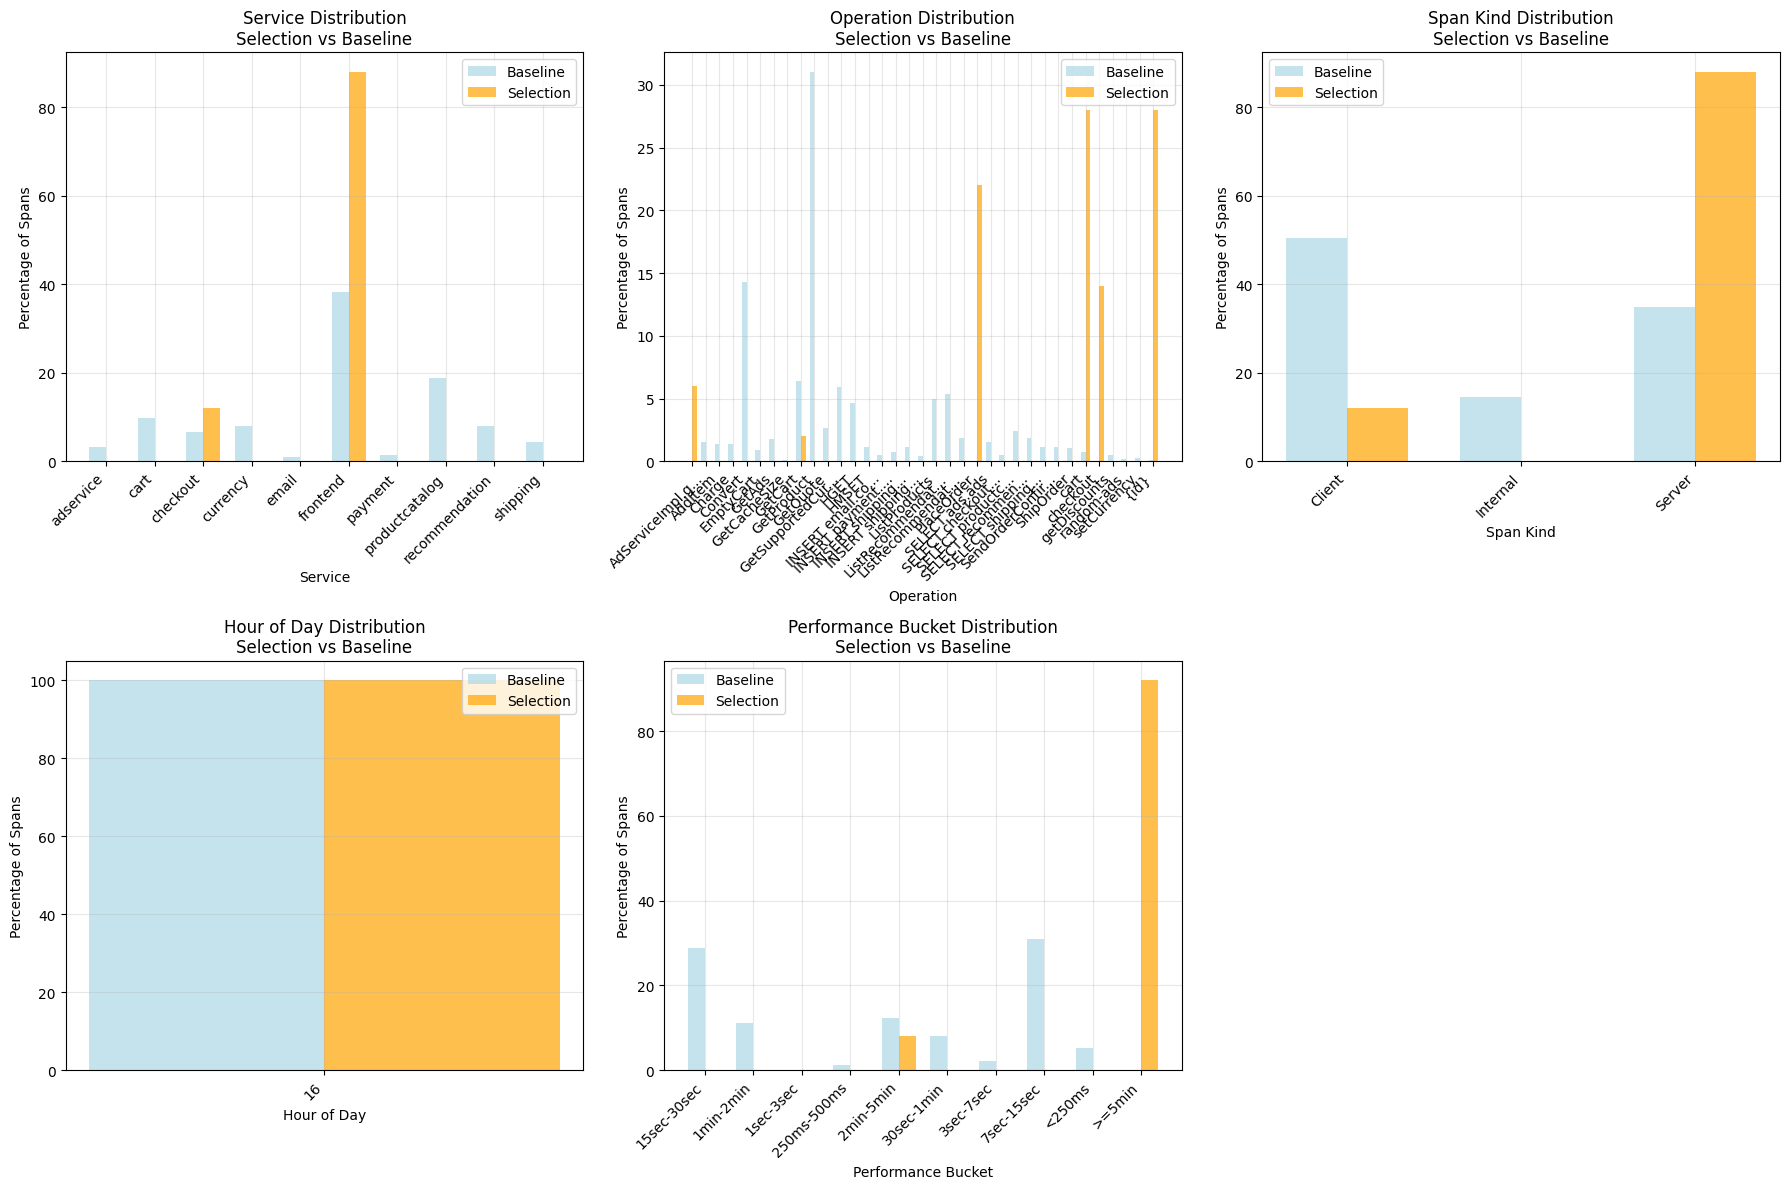


🔍 Key Distinguishing Factors - Very Slow Spans:

Service:
  • frontend: 88.0% in selection vs 38.3% in baseline

Operation:
  • {id}: 28.0% in selection vs 0.1% in baseline
  • cart: 28.0% in selection vs 0.7% in baseline
  • PlaceOrder: 22.0% in selection vs 0.0% in baseline

Span Kind:
  • Server: 88.0% in selection vs 34.8% in baseline

Performance Bucket:
  • >=5min: 92.0% in selection vs 0.0% in baseline


In [16]:
# BubbleUp-style Analysis: Identify and analyze anomalous regions
# Let's define what constitutes "anomalous" spans - those with significantly high duration

def create_bubbleup_analysis(df, selection_criteria, title_suffix=""):
    """
    Create BubbleUp-style paired histogram analysis comparing selection vs baseline
    Args:
        df: DataFrame with span data
        selection_criteria: Boolean mask for selecting anomalous data
        title_suffix: Additional text for plot titles
    """
    
    # Split data into selection (anomalous) and baseline (normal)
    selection_data = df[selection_criteria]
    baseline_data = df[~selection_criteria]
    
    print(f"\n=== BubbleUp Analysis{title_suffix} ===")
    print(f"Selection (Anomalous): {len(selection_data):,} spans")
    print(f"Baseline (Normal): {len(baseline_data):,} spans")
    print(f"Selection represents {len(selection_data)/len(df)*100:.1f}% of total data")
    
    if len(selection_data) == 0 or len(baseline_data) == 0:
        print("Insufficient data for comparison")
        return
    
    # Key dimensions to analyze (similar to BubbleUp's approach)
    dimensions_to_analyze = [
        ('service', 'Service'),
        ('operation', 'Operation'), 
        ('Kind', 'Span Kind'),
        ('hour', 'Hour of Day'),
        ('PerformanceBucket', 'Performance Bucket')
    ]
    
    # Filter dimensions that exist in the data
    available_dimensions = [(col, label) for col, label in dimensions_to_analyze if col in df.columns]
    
    # Create paired histograms for each dimension
    n_dims = len(available_dimensions)
    if n_dims == 0:
        print("No suitable dimensions found for analysis")
        return
        
    # Calculate subplot layout
    cols = 3
    rows = (n_dims + cols - 1) // cols
    
    fig, axes = plt.subplots(rows, cols, figsize=(18, 6*rows))
    if rows == 1:
        axes = axes.reshape(1, -1)
    elif n_dims == 1:
        axes = axes.reshape(1, 1)
    
    for idx, (dimension, label) in enumerate(available_dimensions):
        row = idx // cols
        col = idx % cols
        ax = axes[row, col] if rows > 1 or cols > 1 else axes
        
        # Calculate value counts for both groups
        selection_counts = selection_data[dimension].value_counts().sort_index()
        baseline_counts = baseline_data[dimension].value_counts().sort_index()
        
        # Normalize to percentages for fair comparison
        selection_pct = (selection_counts / len(selection_data) * 100).fillna(0)
        baseline_pct = (baseline_counts / len(baseline_data) * 100).fillna(0)
        
        # Get all unique values
        all_values = sorted(set(selection_counts.index) | set(baseline_counts.index))
        
        # Prepare data for plotting
        x_pos = np.arange(len(all_values))
        selection_values = [selection_pct.get(val, 0) for val in all_values]
        baseline_values = [baseline_pct.get(val, 0) for val in all_values]
        
        # Create paired bar chart
        width = 0.35
        ax.bar(x_pos - width/2, baseline_values, width, label='Baseline', alpha=0.7, color='lightblue')
        ax.bar(x_pos + width/2, selection_values, width, label='Selection', alpha=0.7, color='orange')
        
        ax.set_xlabel(label)
        ax.set_ylabel('Percentage of Spans')
        ax.set_title(f'{label} Distribution\nSelection vs Baseline')
        ax.set_xticks(x_pos)
        ax.set_xticklabels([str(val)[:15] + ('...' if len(str(val)) > 15 else '') for val in all_values], 
                          rotation=45, ha='right')
        ax.legend()
        ax.grid(True, alpha=0.3)
    
    # Hide empty subplots
    for idx in range(n_dims, rows * cols):
        row = idx // cols
        col = idx % cols
        if rows > 1 or cols > 1:
            axes[row, col].set_visible(False)
    
    plt.tight_layout()
    plt.show()
    
    # Calculate and display key insights
    print(f"\n🔍 Key Distinguishing Factors{title_suffix}:")
    
    for dimension, label in available_dimensions:
        if dimension not in df.columns:
            continue
            
        # Calculate the most distinctive values
        selection_dist = selection_data[dimension].value_counts(normalize=True)
        baseline_dist = baseline_data[dimension].value_counts(normalize=True)
        
        # Find values that are over-represented in selection
        distinctive_values = []
        for value in selection_dist.index:
            sel_pct = selection_dist.get(value, 0) * 100
            base_pct = baseline_dist.get(value, 0) * 100
            if sel_pct > base_pct + 10:  # At least 10% difference
                distinctive_values.append((value, sel_pct, base_pct))
        
        if distinctive_values:
            print(f"\n{label}:")
            for value, sel_pct, base_pct in sorted(distinctive_values, key=lambda x: x[1]-x[2], reverse=True)[:3]:
                print(f"  • {value}: {sel_pct:.1f}% in selection vs {base_pct:.1f}% in baseline")

# Example 1: Analyze very slow spans (top 5% by duration)
duration_threshold = df_clean['duration_seconds'].quantile(0.95)
slow_spans_mask = df_clean['duration_seconds'] >= duration_threshold

print(f"Analyzing spans with duration >= {duration_threshold:.2f} seconds (top 5%)")
create_bubbleup_analysis(df_clean, slow_spans_mask, " - Very Slow Spans")


Analyzing anomalous frontend spans (duration >= 264.57 seconds)

=== BubbleUp Analysis - Frontend Service Anomalies ===
Selection (Anomalous): 41 spans
Baseline (Normal): 959 spans
Selection represents 4.1% of total data


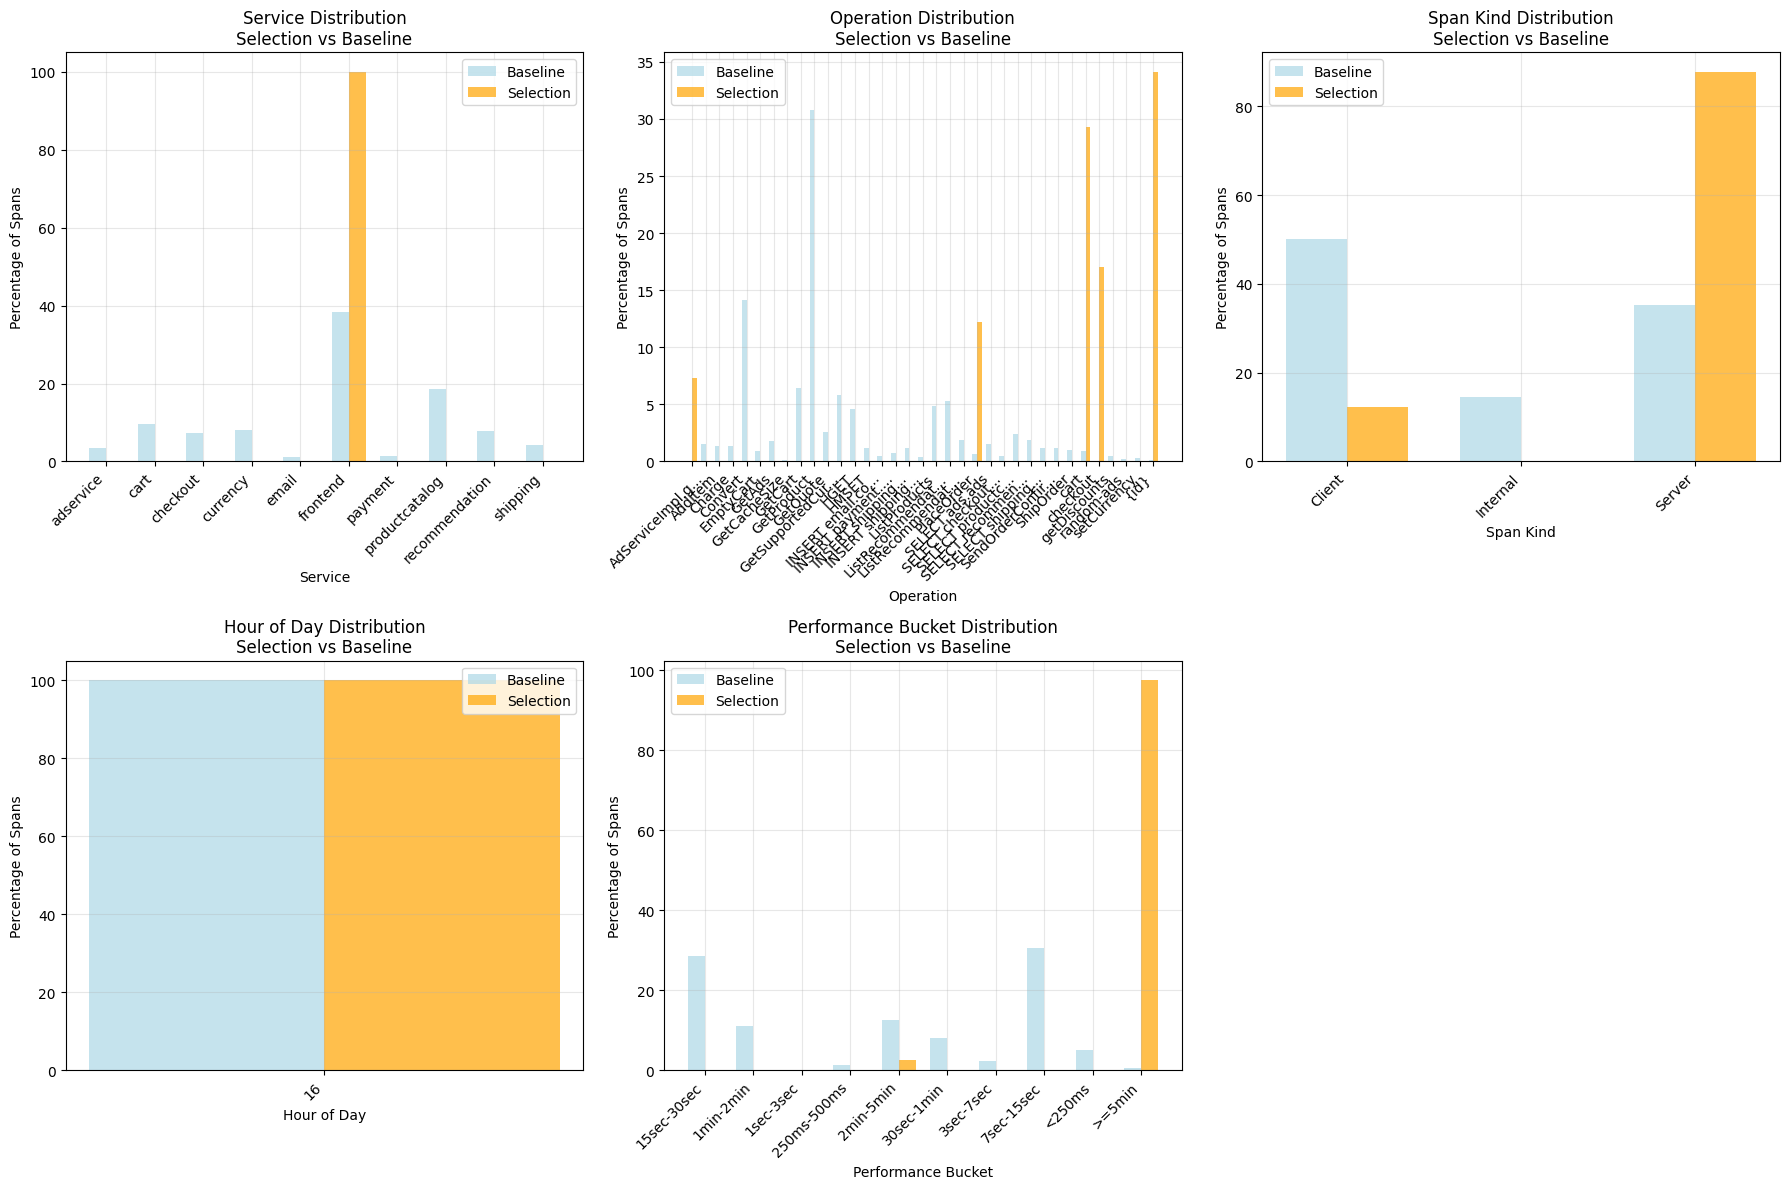


🔍 Key Distinguishing Factors - Frontend Service Anomalies:

Service:
  • frontend: 100.0% in selection vs 38.3% in baseline

Operation:
  • {id}: 34.1% in selection vs 0.1% in baseline
  • cart: 29.3% in selection vs 0.9% in baseline
  • checkout: 17.1% in selection vs 0.0% in baseline

Span Kind:
  • Server: 87.8% in selection vs 35.3% in baseline

Performance Bucket:
  • >=5min: 97.6% in selection vs 0.6% in baseline


In [17]:
# Example 2: Analyze service-specific anomalies
# Let's look at the frontend service which has many spans - identify its anomalies

frontend_data = df_clean[df_clean['service'] == 'frontend']
if len(frontend_data) > 0:
    # Define anomalous frontend spans as those in top 10% duration for frontend
    frontend_threshold = frontend_data['duration_seconds'].quantile(0.90)
    frontend_anomaly_mask = (df_clean['service'] == 'frontend') & (df_clean['duration_seconds'] >= frontend_threshold)
    
    print(f"\nAnalyzing anomalous frontend spans (duration >= {frontend_threshold:.2f} seconds)")
    create_bubbleup_analysis(df_clean, frontend_anomaly_mask, " - Frontend Service Anomalies")


EXAMPLE: Analyzing Recommendation Service Hot Spot

Analyzing heatmap region: Services: recommendation; Duration >= 50s

=== BubbleUp Analysis - Region: Services: recommendation; Duration >= 50s ===
Selection (Anomalous): 56 spans
Baseline (Normal): 944 spans
Selection represents 5.6% of total data


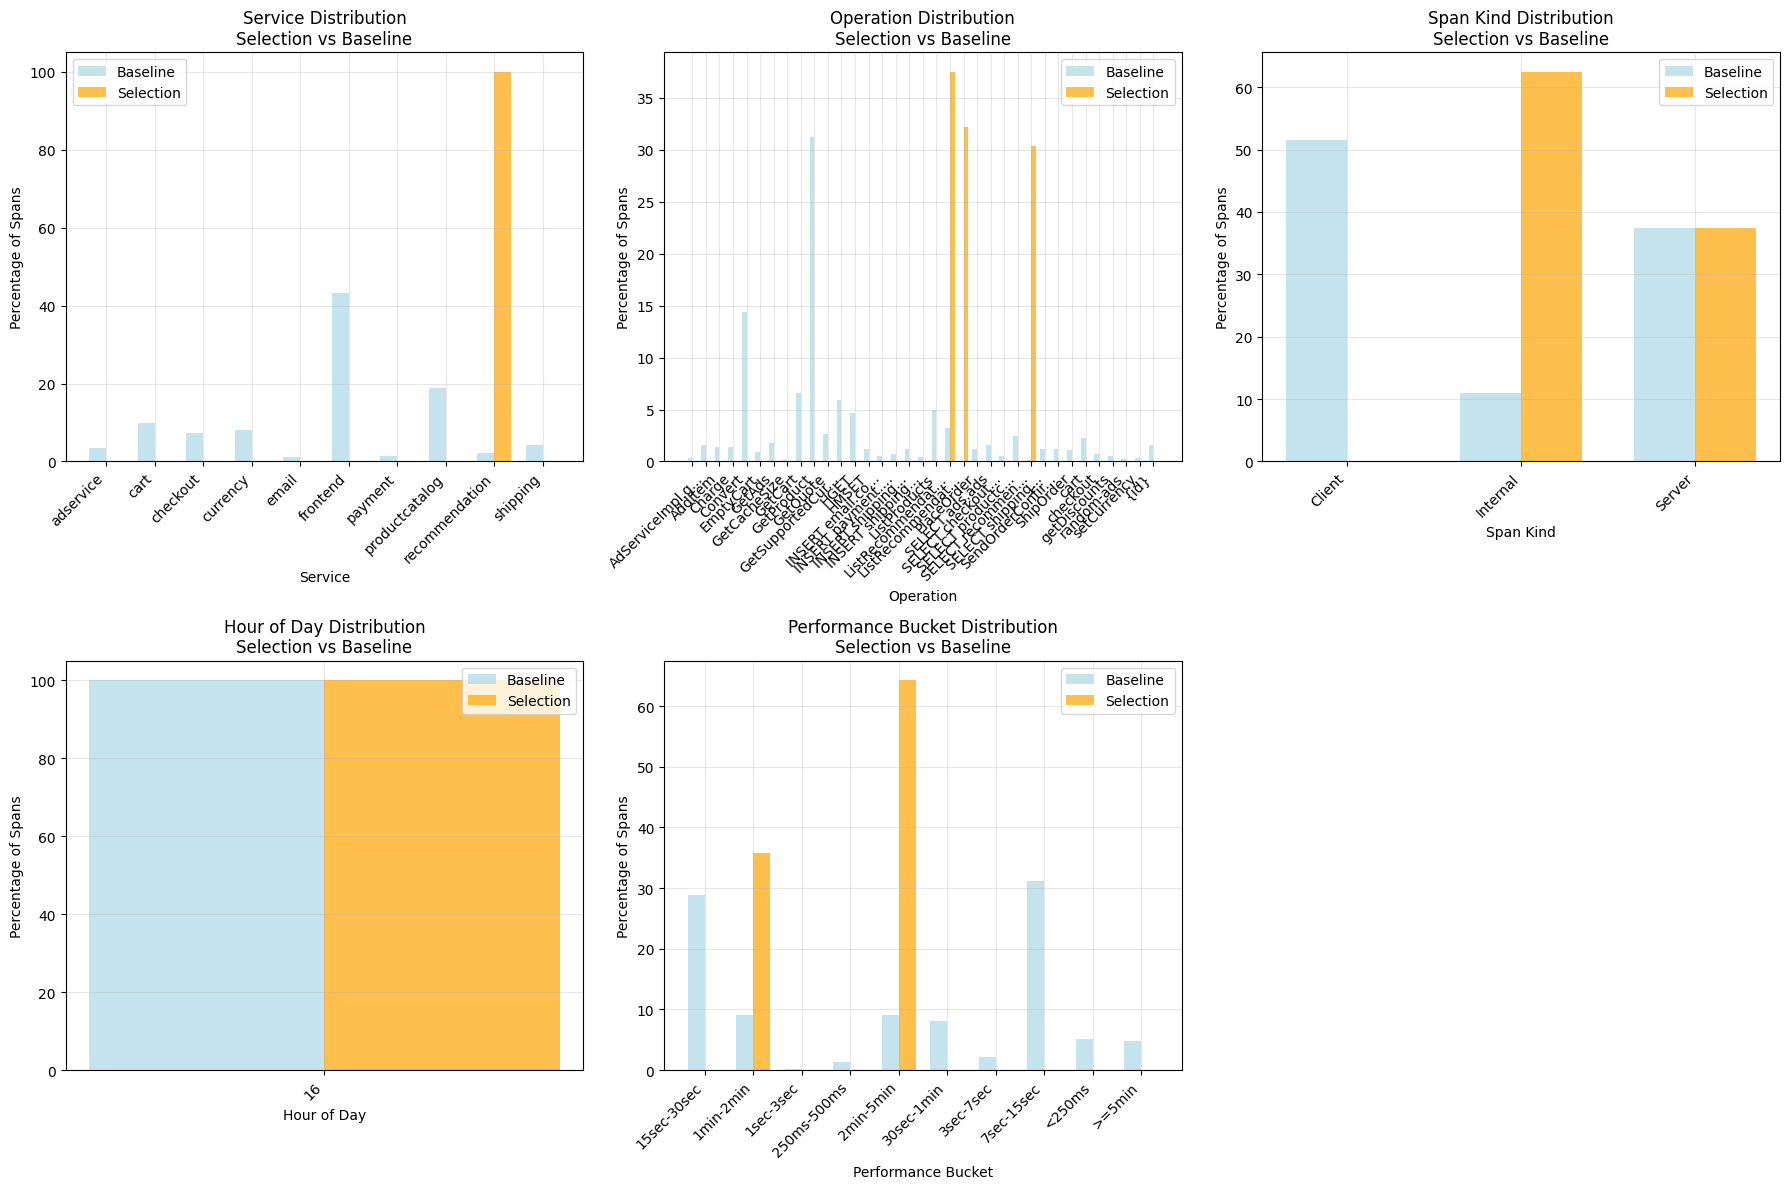


🔍 Key Distinguishing Factors - Region: Services: recommendation; Duration >= 50s:

Service:
  • recommendation: 100.0% in selection vs 2.1% in baseline

Operation:
  • ListRecommendations: 37.5% in selection vs 3.2% in baseline
  • ListRecommendationsFunction: 32.1% in selection vs 0.0% in baseline
  • SELECT recommendation.products: 30.4% in selection vs 0.1% in baseline

Span Kind:
  • Internal: 62.5% in selection vs 11.0% in baseline

Performance Bucket:
  • 2min-5min: 64.3% in selection vs 9.0% in baseline
  • 1min-2min: 35.7% in selection vs 9.1% in baseline


In [18]:
# Example 3: Interactive Heatmap Region Selection
# Create a function to analyze any user-defined region of the heatmap

def analyze_heatmap_region(service_list=None, operation_list=None, duration_min=None, duration_max=None):
    """
    Analyze a specific region of the service-operation heatmap
    Args:
        service_list: List of services to include in selection
        operation_list: List of operations to include in selection  
        duration_min: Minimum duration threshold
        duration_max: Maximum duration threshold
    """
    
    # Build selection criteria
    selection_mask = pd.Series(True, index=df_clean.index)
    
    criteria_desc = []
    
    if service_list:
        selection_mask &= df_clean['service'].isin(service_list)
        criteria_desc.append(f"Services: {', '.join(service_list)}")
    
    if operation_list:
        selection_mask &= df_clean['operation'].isin(operation_list)
        criteria_desc.append(f"Operations: {', '.join(operation_list)}")
    
    if duration_min is not None:
        selection_mask &= df_clean['duration_seconds'] >= duration_min
        criteria_desc.append(f"Duration >= {duration_min}s")
        
    if duration_max is not None:
        selection_mask &= df_clean['duration_seconds'] <= duration_max
        criteria_desc.append(f"Duration <= {duration_max}s")
    
    if not criteria_desc:
        print("No selection criteria provided")
        return
    
    region_title = f" - Region: {'; '.join(criteria_desc)}"
    print(f"\nAnalyzing heatmap region: {'; '.join(criteria_desc)}")
    
    create_bubbleup_analysis(df_clean, selection_mask, region_title)

# Example: Analyze the "hot spot" - recommendation service with high-duration operations
print("\n" + "="*80)
print("EXAMPLE: Analyzing Recommendation Service Hot Spot")
print("="*80)
analyze_heatmap_region(
    service_list=['recommendation'], 
    duration_min=50  # Focus on slower recommendation operations
)


AUTOMATED ANOMALY DETECTION AND ANALYSIS

1. Statistical Outliers (> μ + 2σ = 294.79s)

=== BubbleUp Analysis - Statistical Outliers ===
Selection (Anomalous): 46 spans
Baseline (Normal): 954 spans
Selection represents 4.6% of total data


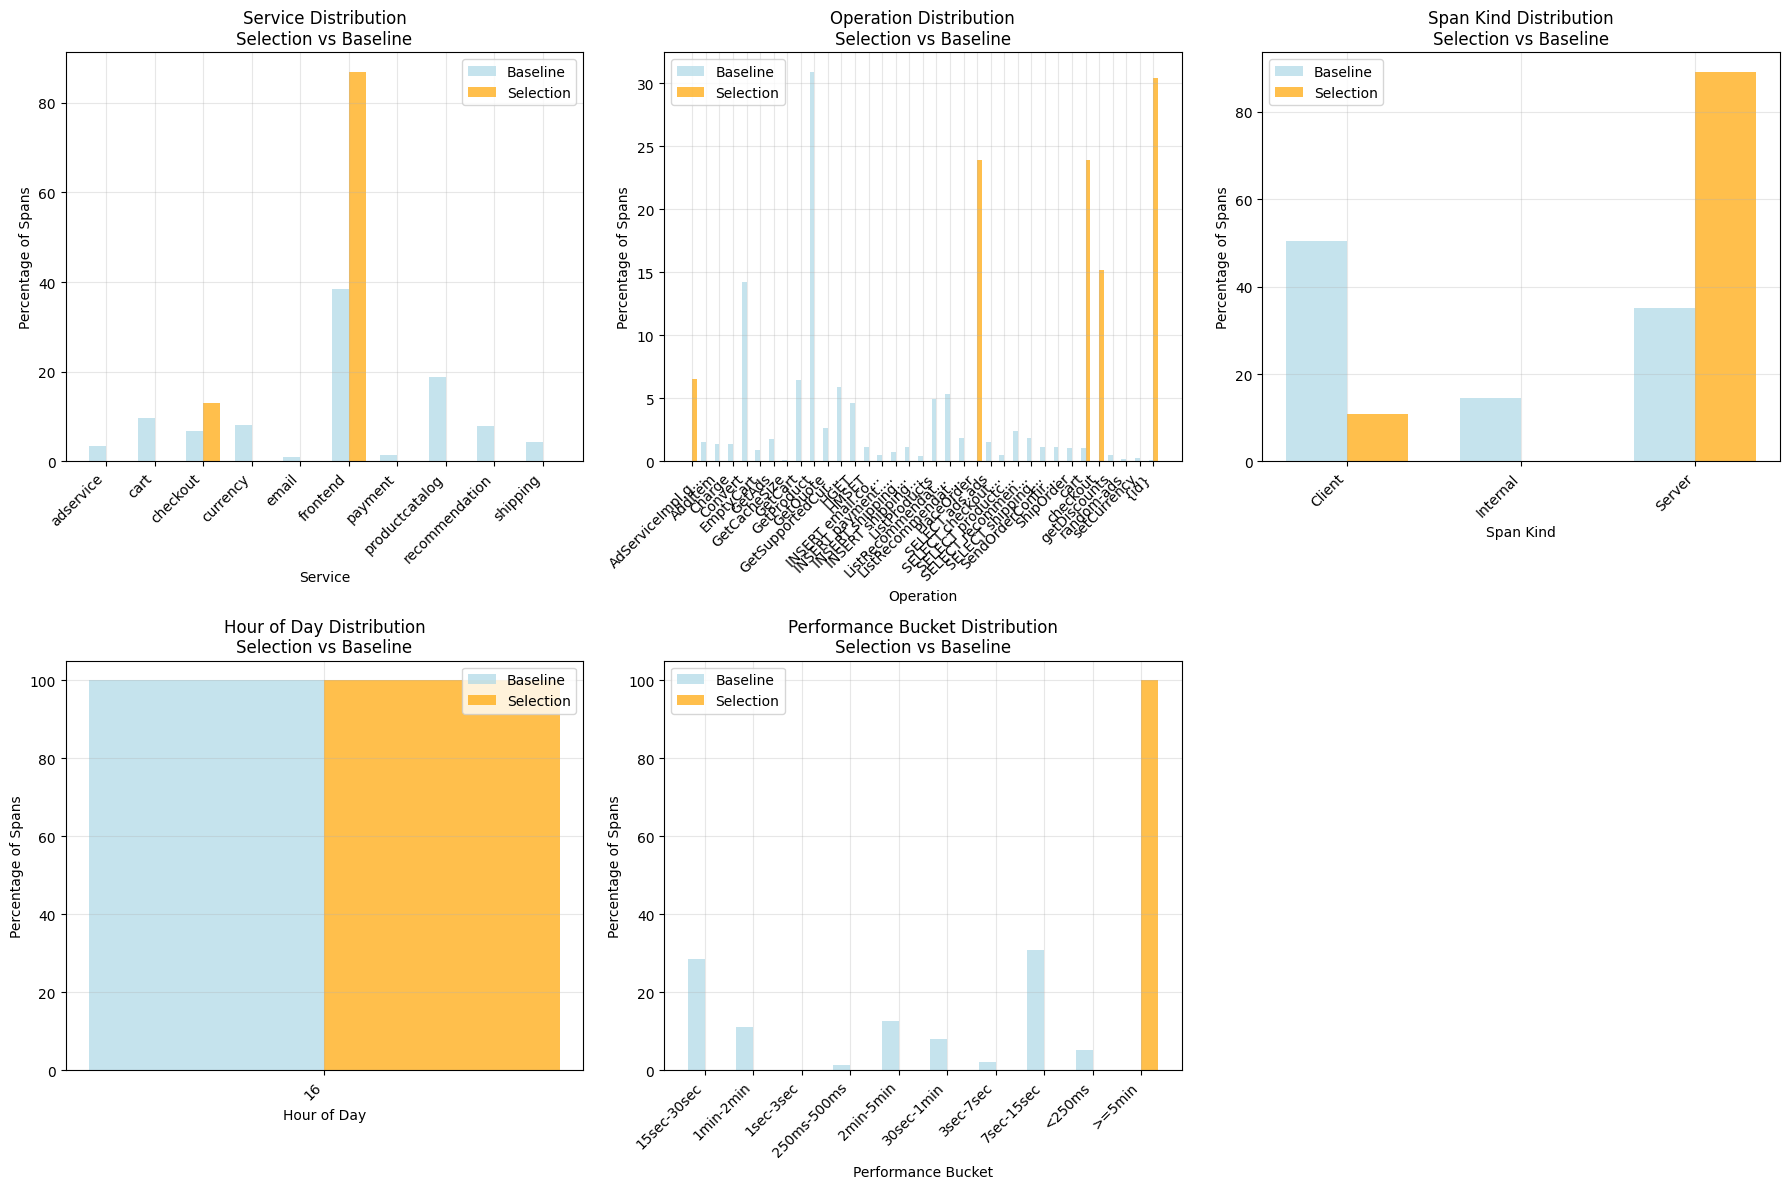


🔍 Key Distinguishing Factors - Statistical Outliers:

Service:
  • frontend: 87.0% in selection vs 38.6% in baseline

Operation:
  • {id}: 30.4% in selection vs 0.1% in baseline
  • PlaceOrder: 23.9% in selection vs 0.0% in baseline
  • cart: 23.9% in selection vs 1.0% in baseline

Span Kind:
  • Server: 89.1% in selection vs 35.0% in baseline

Performance Bucket:
  • >=5min: 100.0% in selection vs 0.0% in baseline

2. Frontend Service Anomalies (>= 174.23s)

=== BubbleUp Analysis - Frontend Anomalies ===
Selection (Anomalous): 62 spans
Baseline (Normal): 938 spans
Selection represents 6.2% of total data


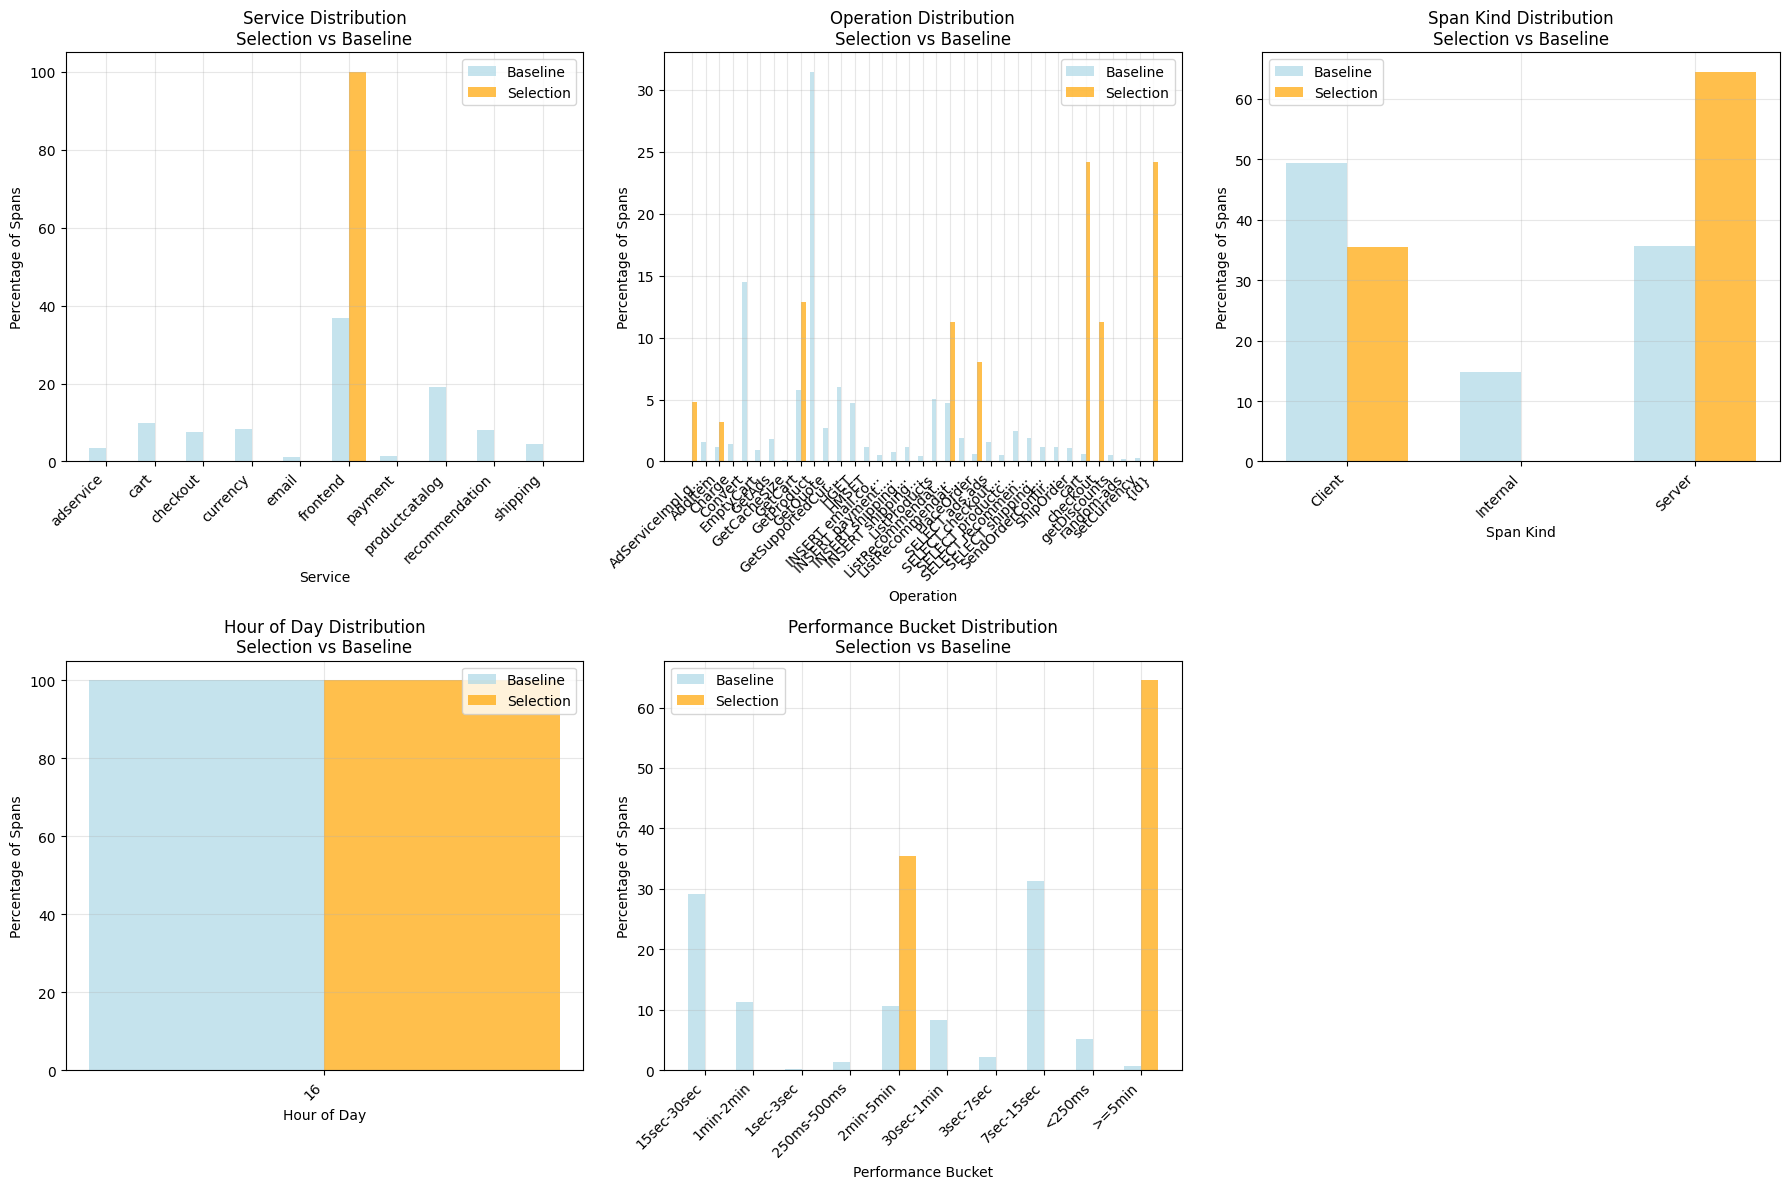


🔍 Key Distinguishing Factors - Frontend Anomalies:

Service:
  • frontend: 100.0% in selection vs 36.9% in baseline

Operation:
  • {id}: 24.2% in selection vs 0.0% in baseline
  • cart: 24.2% in selection vs 0.6% in baseline
  • checkout: 11.3% in selection vs 0.0% in baseline

Span Kind:
  • Server: 64.5% in selection vs 35.7% in baseline

Performance Bucket:
  • >=5min: 64.5% in selection vs 0.6% in baseline
  • 2min-5min: 35.5% in selection vs 10.6% in baseline

2. Productcatalog Service Anomalies (>= 20.26s)

=== BubbleUp Analysis - Productcatalog Anomalies ===
Selection (Anomalous): 27 spans
Baseline (Normal): 973 spans
Selection represents 2.7% of total data


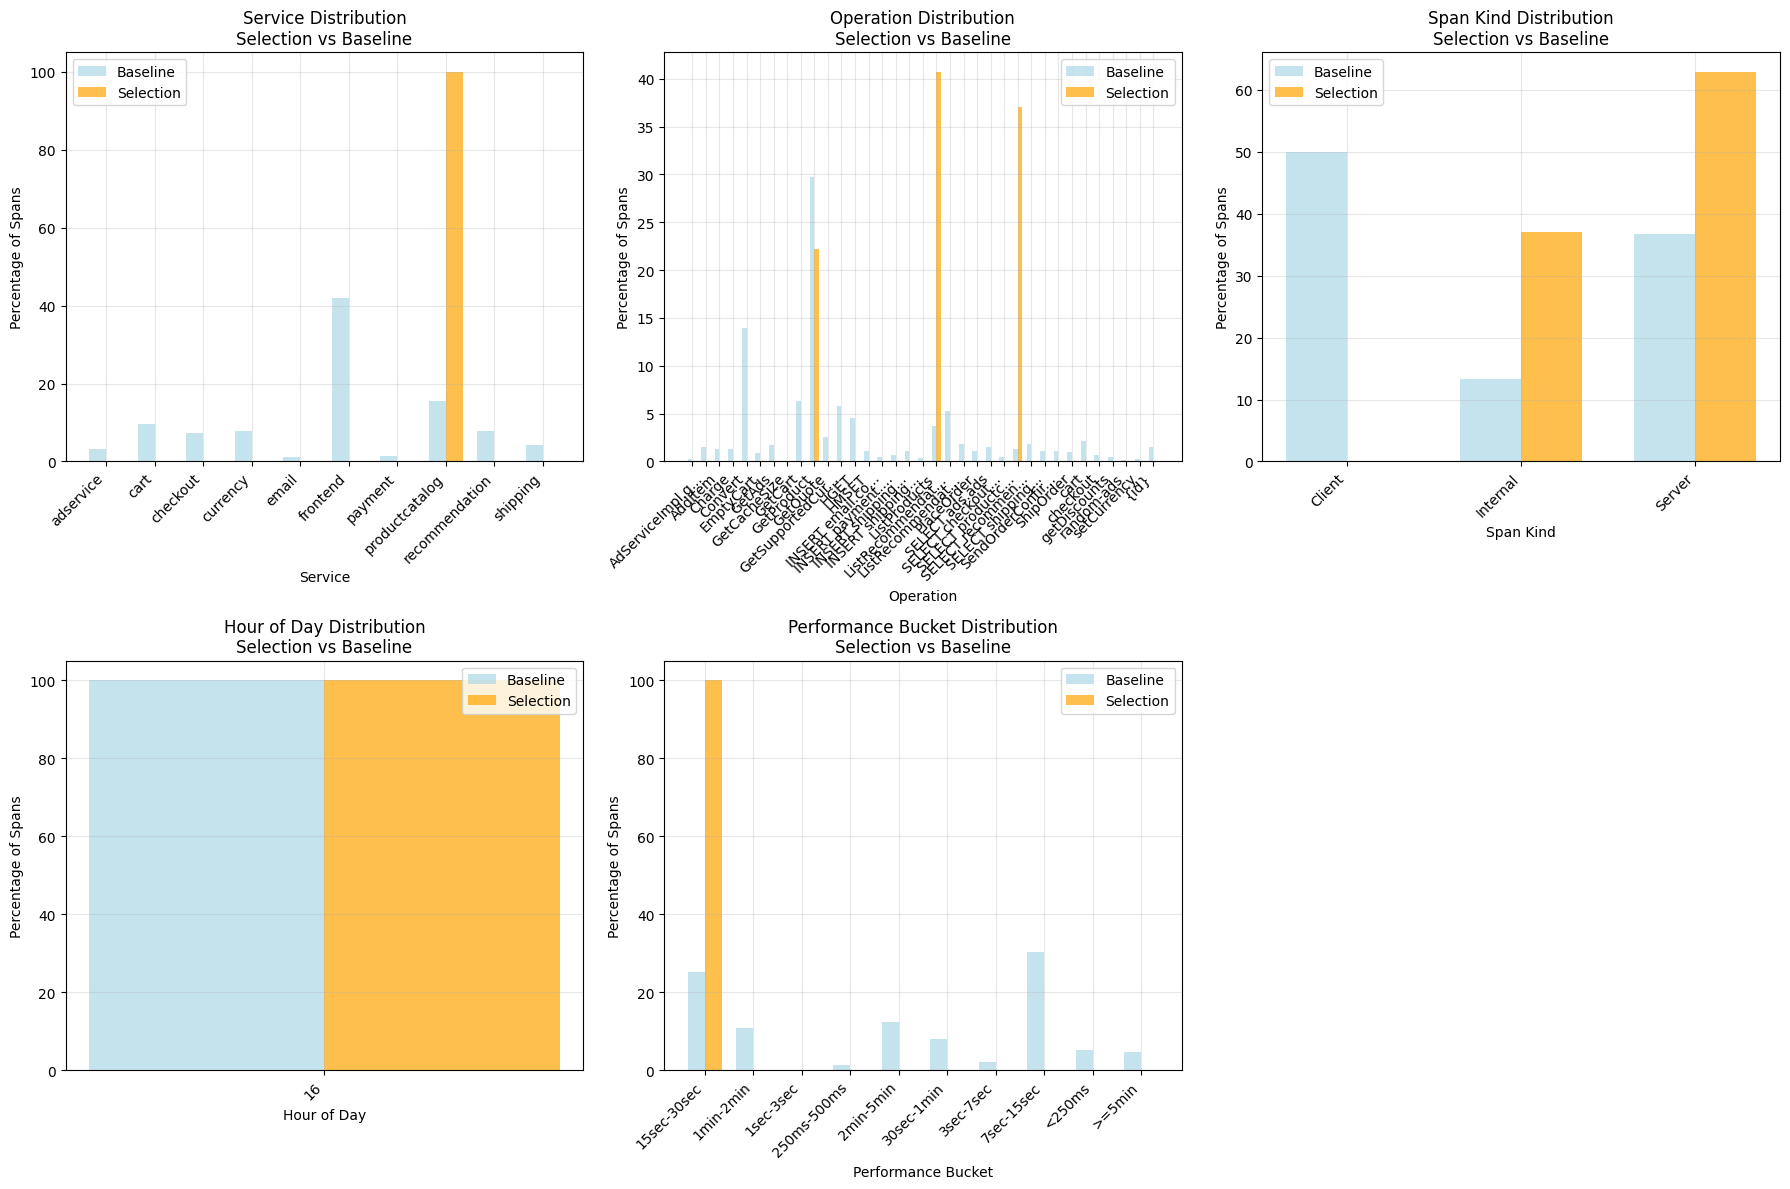


🔍 Key Distinguishing Factors - Productcatalog Anomalies:

Service:
  • productcatalog: 100.0% in selection vs 15.6% in baseline

Operation:
  • ListProducts: 40.7% in selection vs 3.7% in baseline
  • SELECT productcatalog.products: 37.0% in selection vs 1.3% in baseline

Span Kind:
  • Server: 63.0% in selection vs 36.8% in baseline
  • Internal: 37.0% in selection vs 13.3% in baseline

Performance Bucket:
  • 15sec-30sec: 100.0% in selection vs 25.3% in baseline

2. Cart Service Anomalies (>= 156.48s)

=== BubbleUp Analysis - Cart Anomalies ===
Selection (Anomalous): 14 spans
Baseline (Normal): 986 spans
Selection represents 1.4% of total data


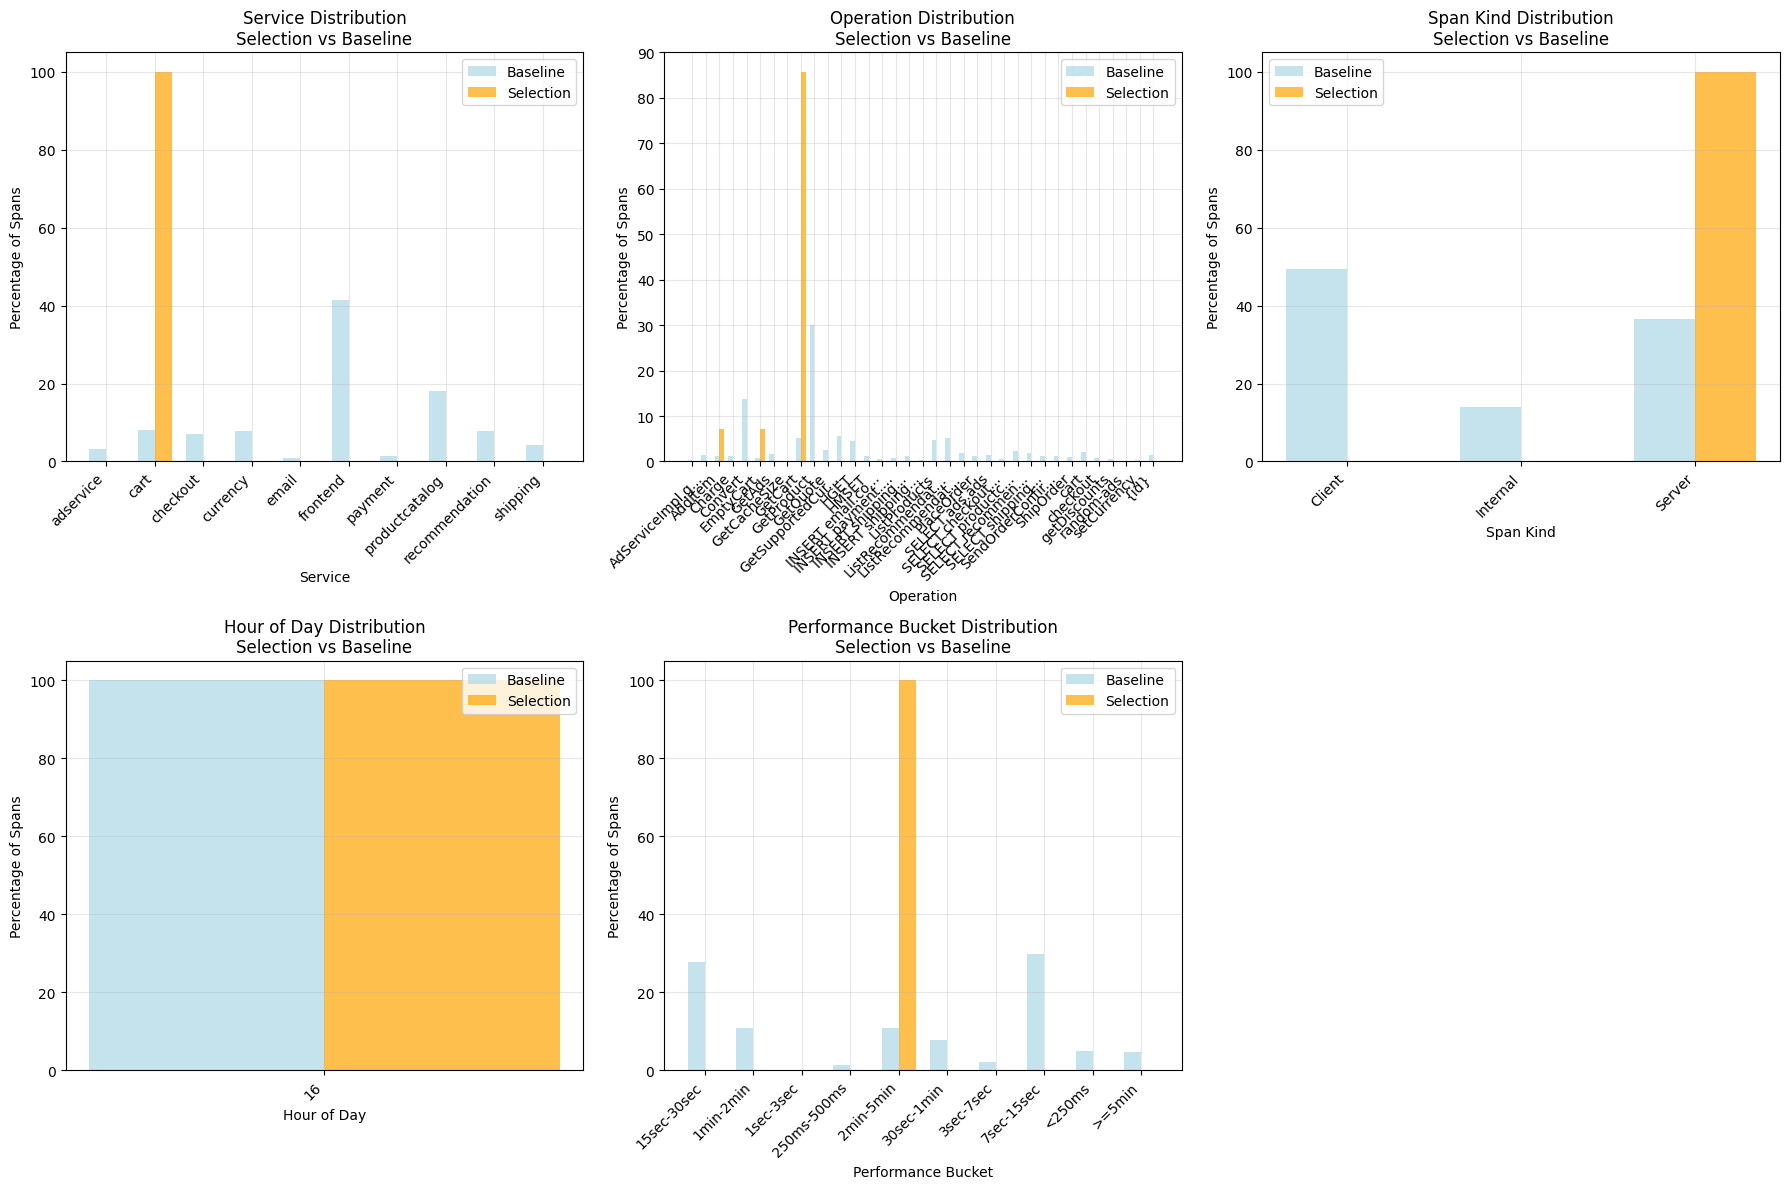


🔍 Key Distinguishing Factors - Cart Anomalies:

Service:
  • cart: 100.0% in selection vs 8.0% in baseline

Operation:
  • GetCart: 85.7% in selection vs 5.1% in baseline

Span Kind:
  • Server: 100.0% in selection vs 36.6% in baseline

Performance Bucket:
  • 2min-5min: 100.0% in selection vs 10.9% in baseline

3. Time-based Anomalies (slow periods: ['16:15'])

=== BubbleUp Analysis - Time-based Anomalies ===
Selection (Anomalous): 600 spans
Baseline (Normal): 400 spans
Selection represents 60.0% of total data


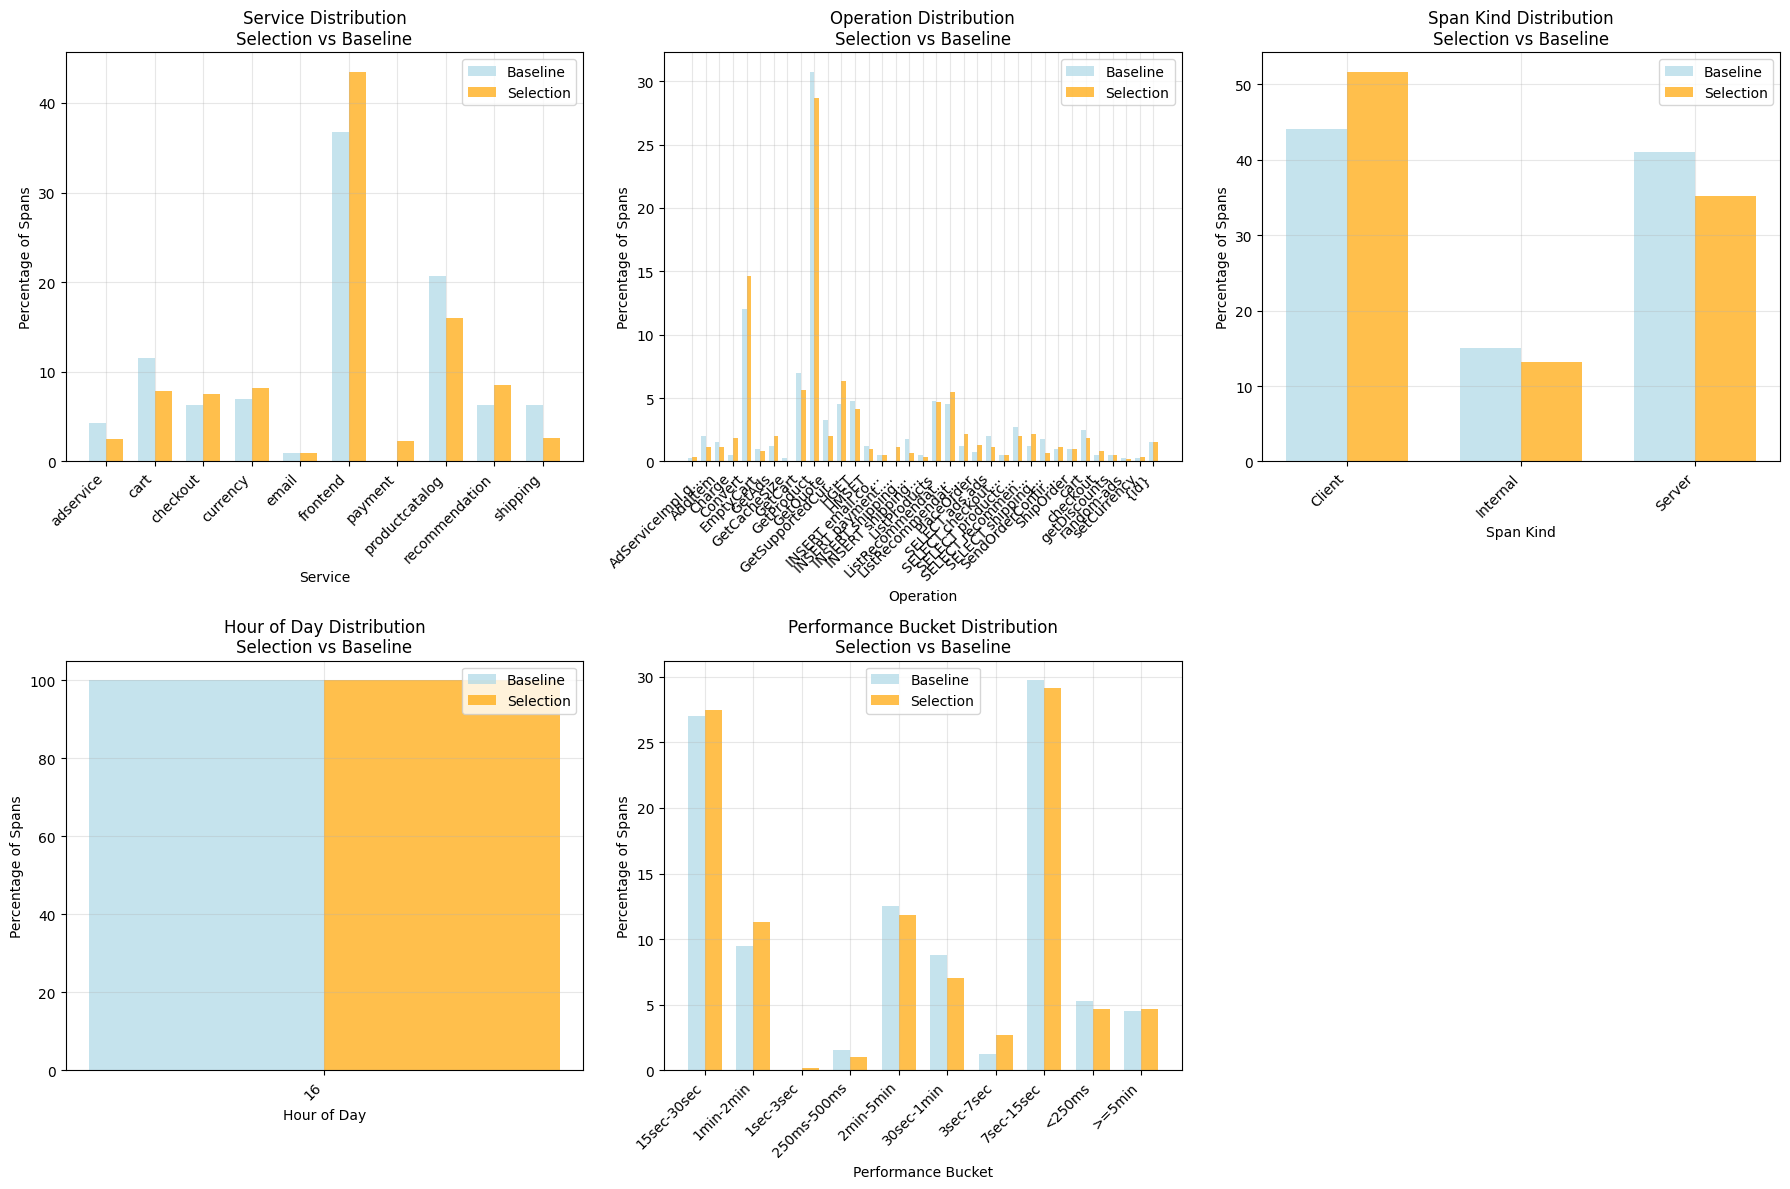


🔍 Key Distinguishing Factors - Time-based Anomalies:


In [19]:
# Example 4: Multi-dimensional Anomaly Detection
# Implement more sophisticated anomaly detection similar to BubbleUp's core analysis loop

def detect_and_analyze_anomalies():
    """
    Automatically detect anomalies using multiple criteria and analyze them
    """
    print("\n" + "="*80)
    print("AUTOMATED ANOMALY DETECTION AND ANALYSIS")
    print("="*80)
    
    # 1. Statistical outliers (beyond 2 standard deviations)
    duration_mean = df_clean['duration_seconds'].mean()
    duration_std = df_clean['duration_seconds'].std()
    statistical_outliers = df_clean['duration_seconds'] > (duration_mean + 2 * duration_std)
    
    if statistical_outliers.sum() > 0:
        print(f"\n1. Statistical Outliers (> μ + 2σ = {duration_mean + 2 * duration_std:.2f}s)")
        create_bubbleup_analysis(df_clean, statistical_outliers, " - Statistical Outliers")
    
    # 2. Service-specific anomalies for each major service
    major_services = df_clean['service'].value_counts().head(3).index
    
    for service in major_services:
        service_data = df_clean[df_clean['service'] == service]
        if len(service_data) < 10:
            continue
            
        # Define anomalies as top 15% duration for this service
        service_threshold = service_data['duration_seconds'].quantile(0.85)
        service_anomalies = (df_clean['service'] == service) & (df_clean['duration_seconds'] >= service_threshold)
        
        if service_anomalies.sum() > 0:
            print(f"\n2. {service.title()} Service Anomalies (>= {service_threshold:.2f}s)")
            create_bubbleup_analysis(df_clean, service_anomalies, f" - {service.title()} Anomalies")
    
    # 3. Time-based anomalies (if we have time variance)
    if df_clean['time_bucket'].nunique() > 1:
        # Find time periods with unusually high average duration
        time_avg_durations = df_clean.groupby('time_bucket')['duration_seconds'].mean()
        time_threshold = time_avg_durations.quantile(0.8)
        slow_time_periods = time_avg_durations[time_avg_durations >= time_threshold].index
        
        if len(slow_time_periods) > 0:
            time_anomalies = df_clean['time_bucket'].isin(slow_time_periods)
            print(f"\n3. Time-based Anomalies (slow periods: {list(slow_time_periods)})")
            create_bubbleup_analysis(df_clean, time_anomalies, " - Time-based Anomalies")

# Run automated anomaly detection
detect_and_analyze_anomalies()


ITERATIVE DRILL-DOWN ANALYSIS (BubbleUp Style)

--- ITERATION 1 ---
Current selection: 50 spans (5.0% of total)
Most distinguishing factor: PerformanceBucket = '>=5min'
Separation score: 0.920

=== BubbleUp Analysis - Iteration 1 ===
Selection (Anomalous): 50 spans
Baseline (Normal): 950 spans
Selection represents 5.0% of total data


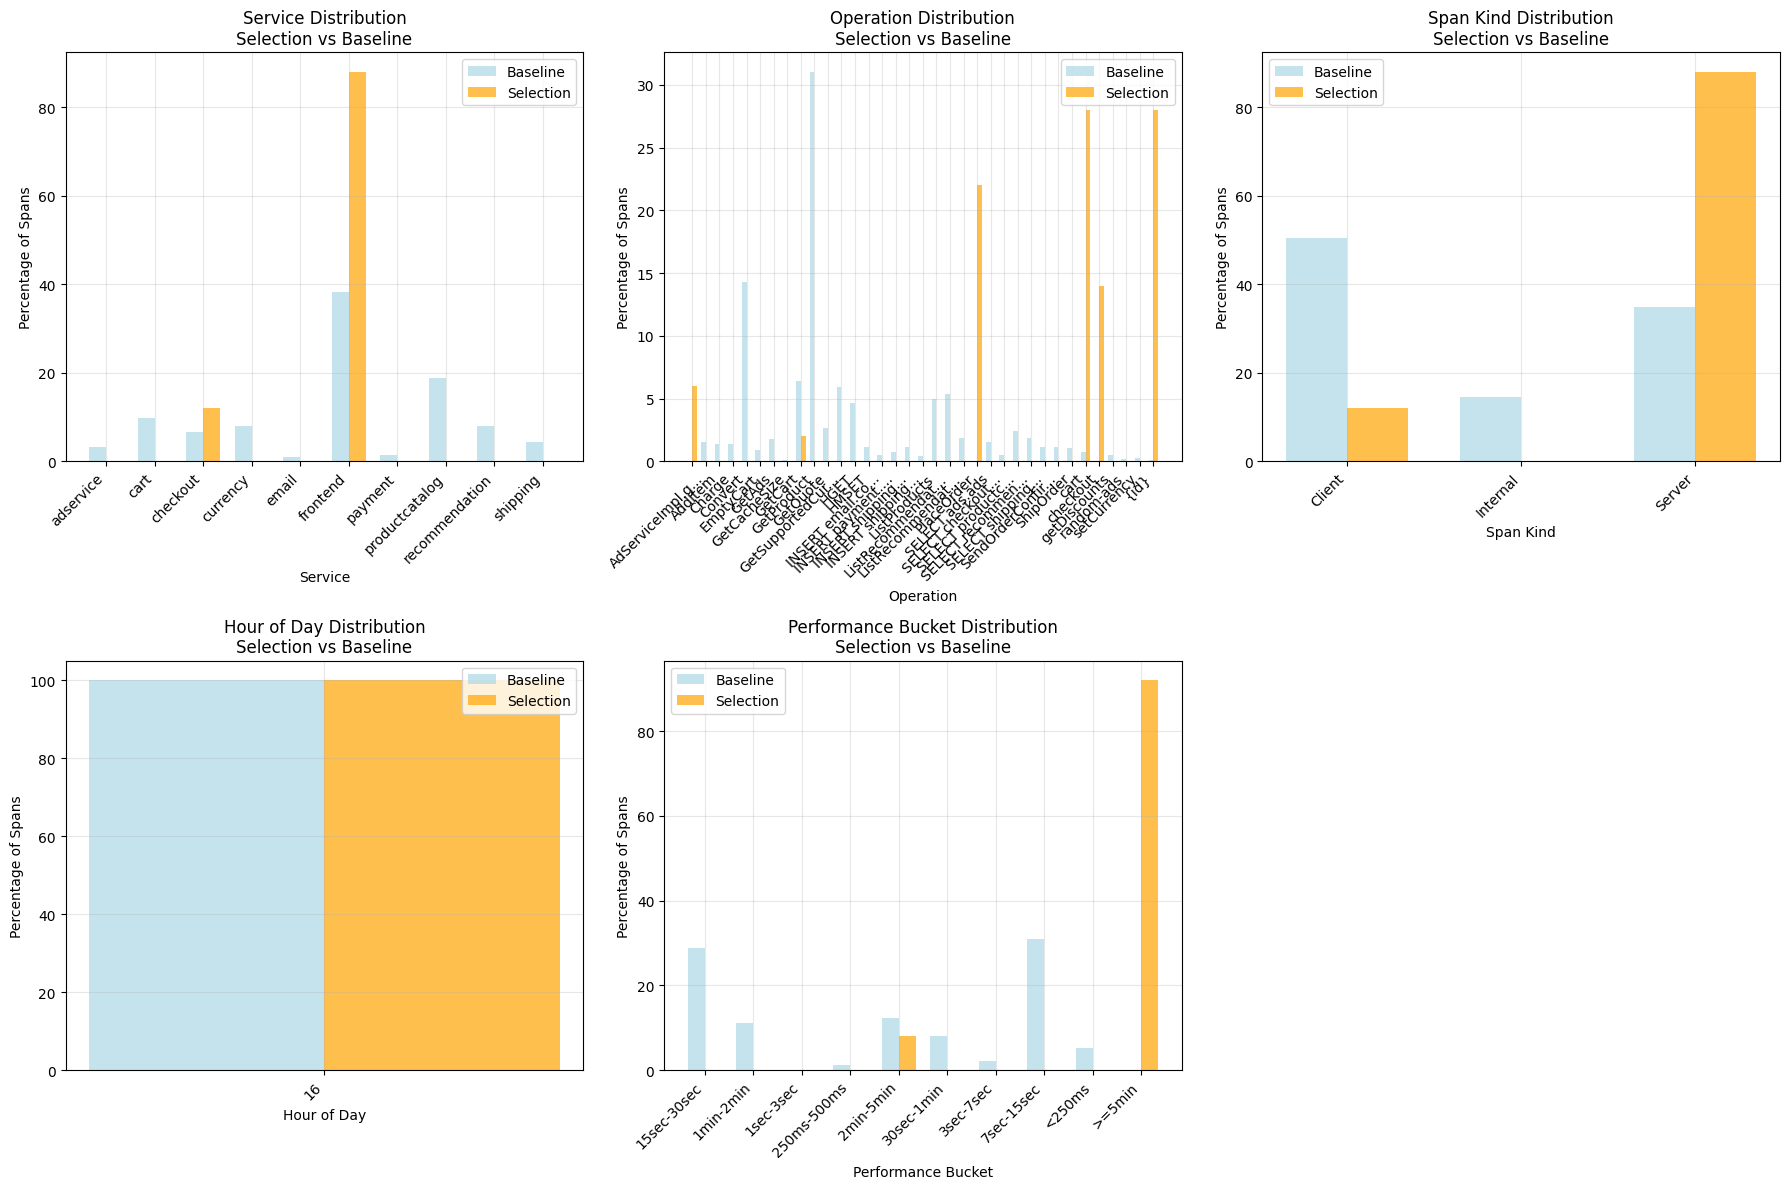


🔍 Key Distinguishing Factors - Iteration 1:

Service:
  • frontend: 88.0% in selection vs 38.3% in baseline

Operation:
  • {id}: 28.0% in selection vs 0.1% in baseline
  • cart: 28.0% in selection vs 0.7% in baseline
  • PlaceOrder: 22.0% in selection vs 0.0% in baseline

Span Kind:
  • Server: 88.0% in selection vs 34.8% in baseline

Performance Bucket:
  • >=5min: 92.0% in selection vs 0.0% in baseline
Refining selection to focus on PerformanceBucket = '>=5min'

--- ITERATION 2 ---
Current selection: 46 spans (4.6% of total)
Most distinguishing factor: PerformanceBucket = '>=5min'
Separation score: 1.000

=== BubbleUp Analysis - Iteration 2 ===
Selection (Anomalous): 46 spans
Baseline (Normal): 954 spans
Selection represents 4.6% of total data


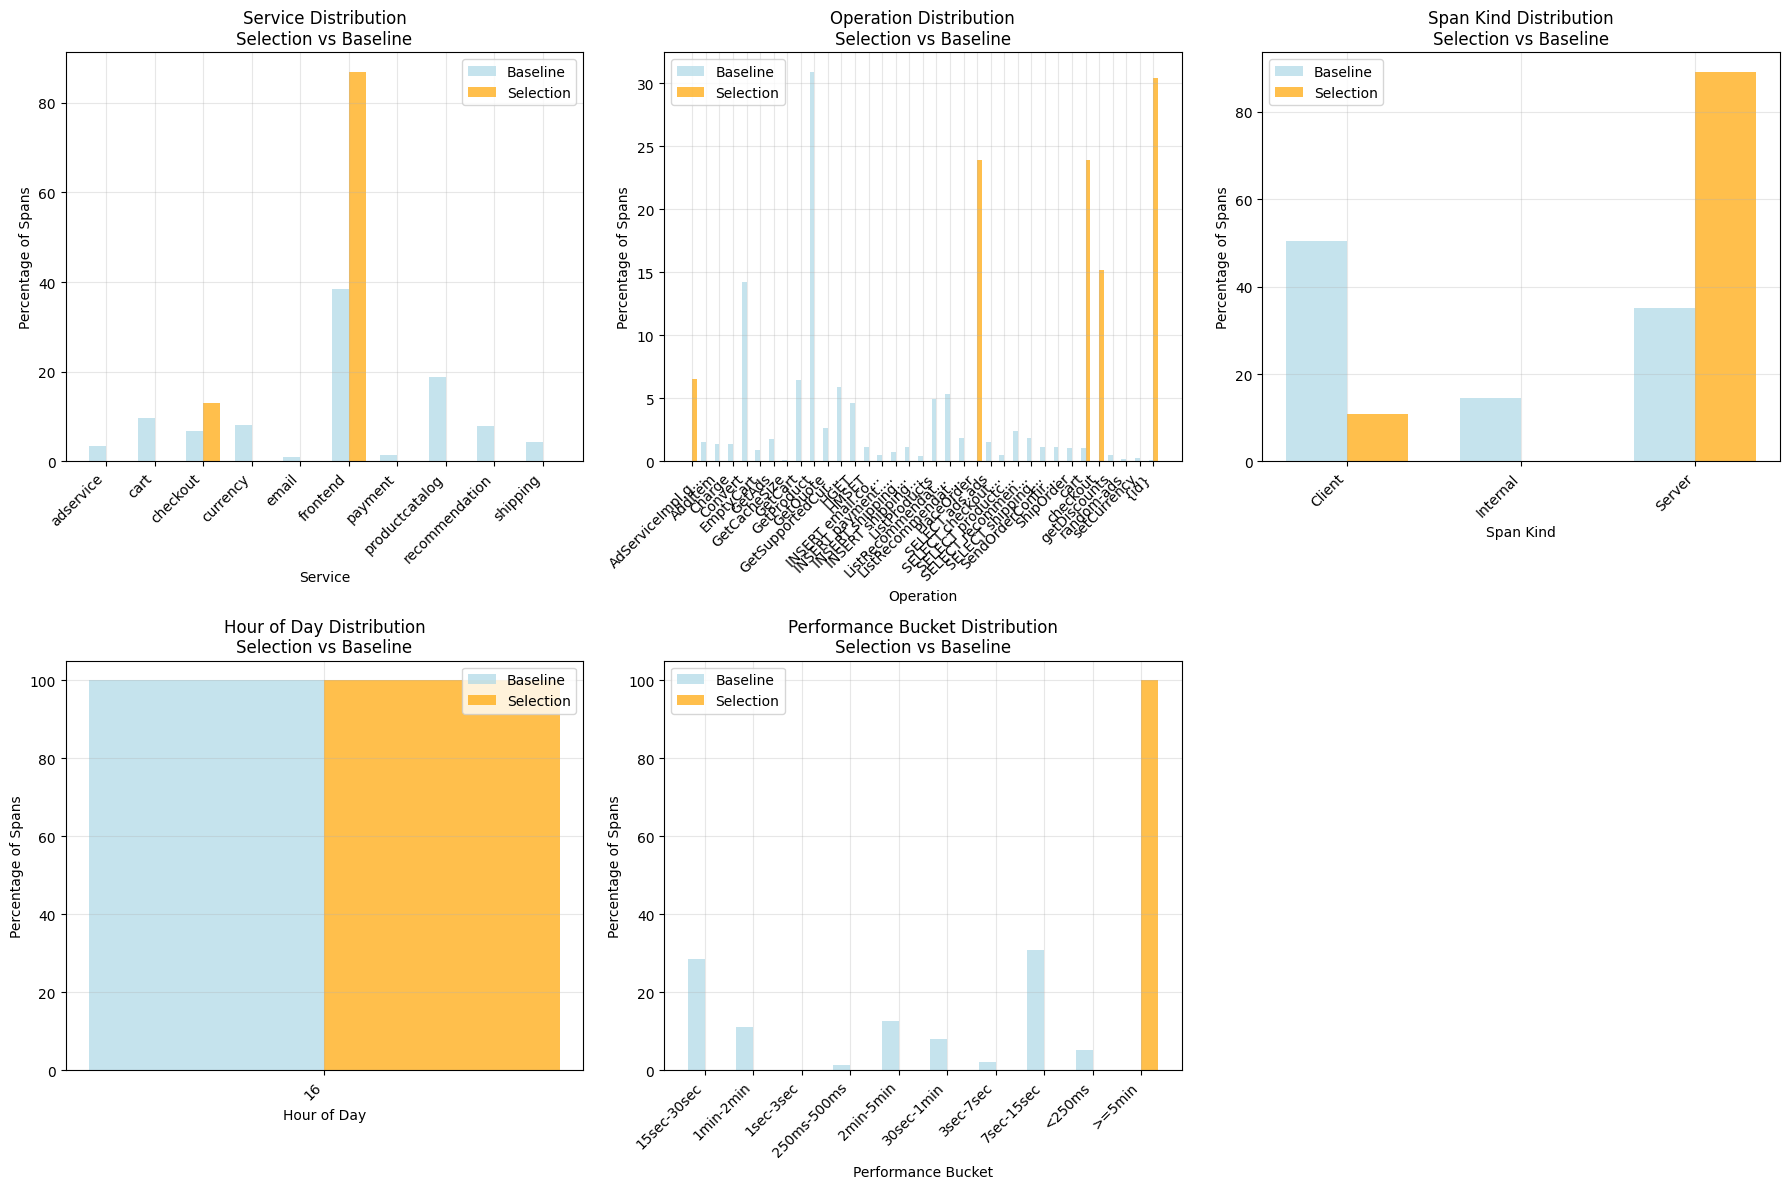


🔍 Key Distinguishing Factors - Iteration 2:

Service:
  • frontend: 87.0% in selection vs 38.6% in baseline

Operation:
  • {id}: 30.4% in selection vs 0.1% in baseline
  • PlaceOrder: 23.9% in selection vs 0.0% in baseline
  • cart: 23.9% in selection vs 1.0% in baseline

Span Kind:
  • Server: 89.1% in selection vs 35.0% in baseline

Performance Bucket:
  • >=5min: 100.0% in selection vs 0.0% in baseline
Refining selection to focus on PerformanceBucket = '>=5min'

--- ITERATION 3 ---
Current selection: 46 spans (4.6% of total)
Most distinguishing factor: PerformanceBucket = '>=5min'
Separation score: 1.000

=== BubbleUp Analysis - Iteration 3 ===
Selection (Anomalous): 46 spans
Baseline (Normal): 954 spans
Selection represents 4.6% of total data


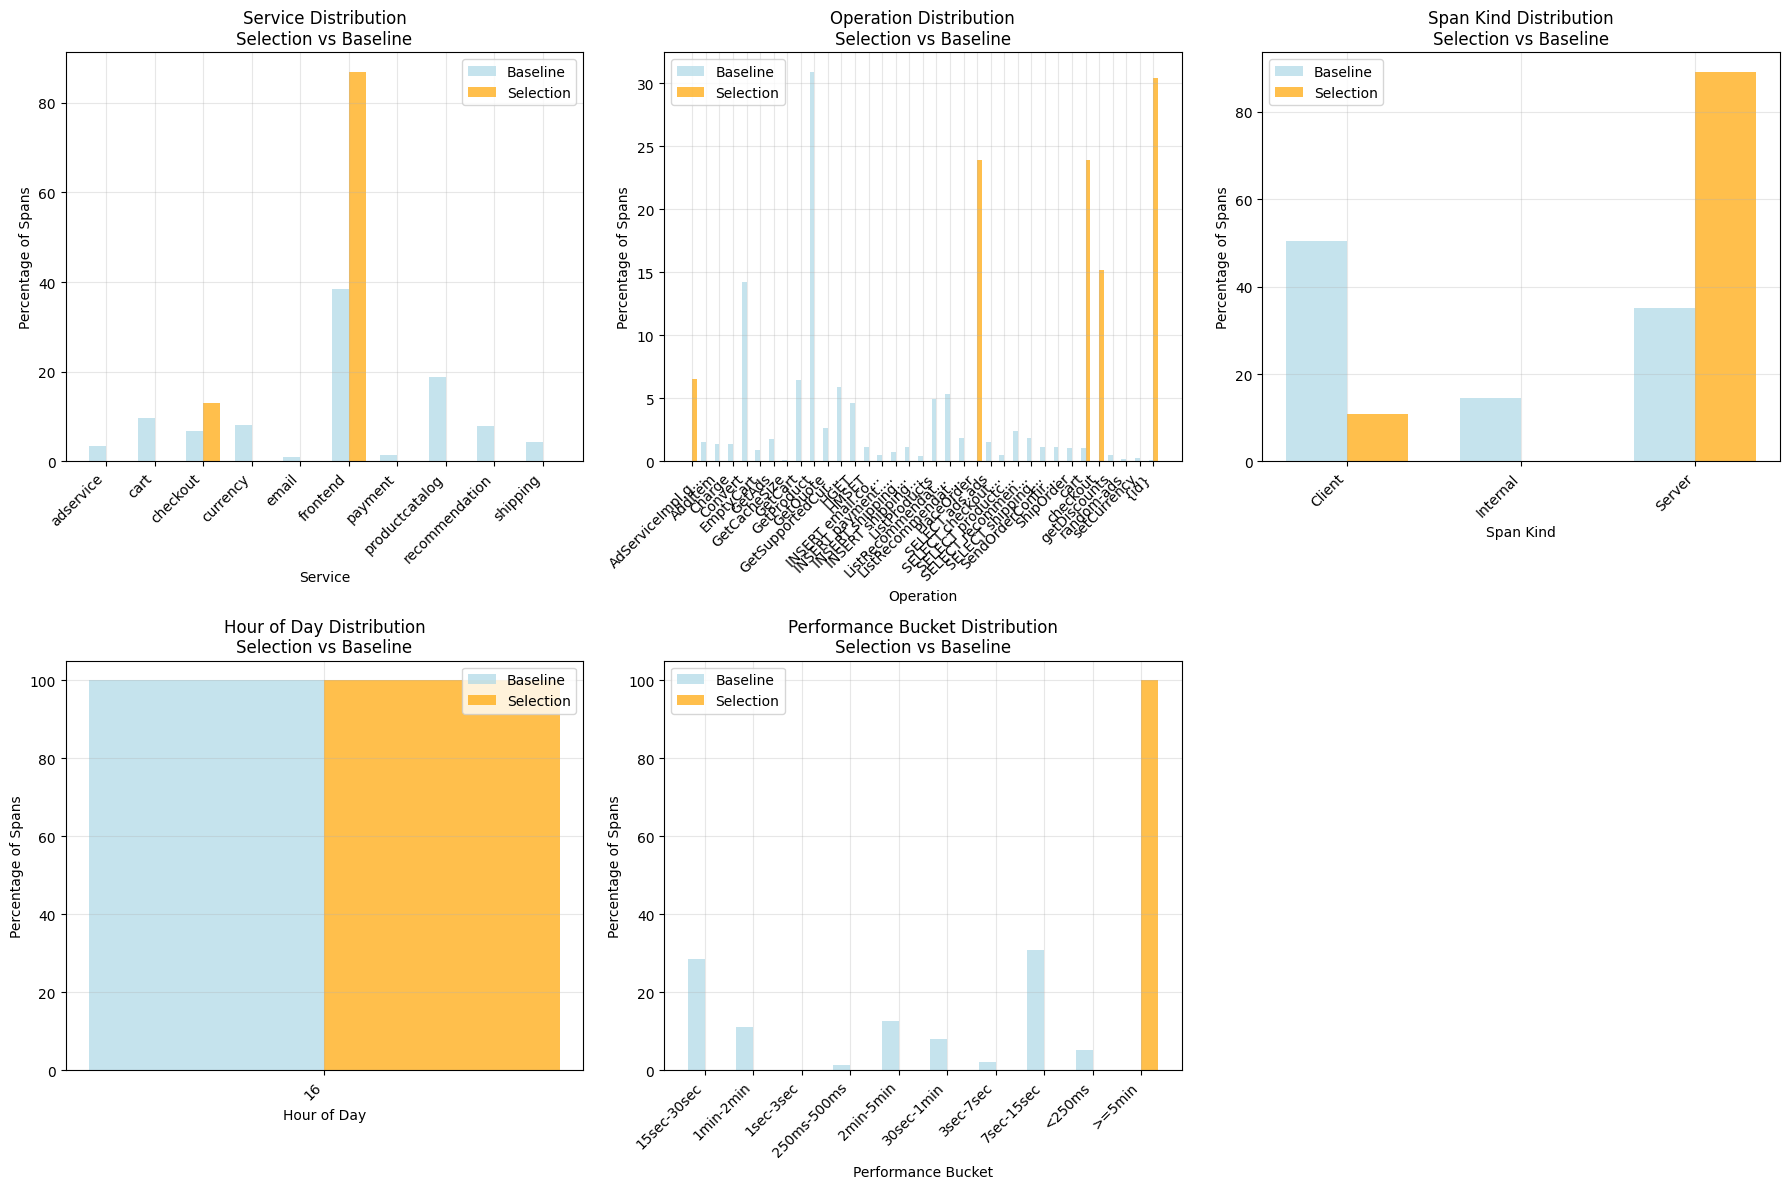


🔍 Key Distinguishing Factors - Iteration 3:

Service:
  • frontend: 87.0% in selection vs 38.6% in baseline

Operation:
  • {id}: 30.4% in selection vs 0.1% in baseline
  • PlaceOrder: 23.9% in selection vs 0.0% in baseline
  • cart: 23.9% in selection vs 1.0% in baseline

Span Kind:
  • Server: 89.1% in selection vs 35.0% in baseline

Performance Bucket:
  • >=5min: 100.0% in selection vs 0.0% in baseline


In [20]:
# Example 5: BubbleUp-style Drill-down Analysis
# Implement iterative analysis similar to BubbleUp's core analysis loop

def iterative_drill_down(initial_selection_mask, max_iterations=3):
    """
    Implement BubbleUp's iterative drill-down approach
    Starting with an anomalous selection, iteratively refine to find root causes
    """
    print("\n" + "="*80)
    print("ITERATIVE DRILL-DOWN ANALYSIS (BubbleUp Style)")
    print("="*80)
    
    current_selection = initial_selection_mask.copy()
    
    for iteration in range(max_iterations):
        print(f"\n--- ITERATION {iteration + 1} ---")
        
        selection_data = df_clean[current_selection]
        baseline_data = df_clean[~current_selection]
        
        if len(selection_data) < 5:
            print("Selection too small for further analysis")
            break
            
        print(f"Current selection: {len(selection_data)} spans ({len(selection_data)/len(df_clean)*100:.1f}% of total)")
        
        # Find the most distinguishing dimension
        best_dimension = None
        best_value = None
        best_separation_score = 0
        
        dimensions_to_check = ['service', 'operation', 'Kind', 'PerformanceBucket']
        
        for dimension in dimensions_to_check:
            if dimension not in df_clean.columns:
                continue
                
            # Calculate separation scores for each value in this dimension
            for value in df_clean[dimension].unique():
                if pd.isna(value):
                    continue
                    
                # Calculate how much this value is over-represented in selection
                sel_rate = (selection_data[dimension] == value).mean()
                base_rate = (baseline_data[dimension] == value).mean()
                
                # Separation score: difference in representation rates
                separation_score = sel_rate - base_rate
                
                if separation_score > best_separation_score and sel_rate > 0.1:  # At least 10% of selection
                    best_separation_score = separation_score
                    best_dimension = dimension
                    best_value = value
        
        if best_dimension is None:
            print("No strong distinguishing factors found")
            break
            
        print(f"Most distinguishing factor: {best_dimension} = '{best_value}'")
        print(f"Separation score: {best_separation_score:.3f}")
        
        # Show current analysis
        create_bubbleup_analysis(df_clean, current_selection, f" - Iteration {iteration + 1}")
        
        # Refine selection for next iteration - focus on the distinguishing factor
        if iteration < max_iterations - 1:
            refined_selection = current_selection & (df_clean[best_dimension] == best_value)
            
            if refined_selection.sum() < 5:
                print("Refined selection would be too small, stopping iteration")
                break
                
            current_selection = refined_selection
            print(f"Refining selection to focus on {best_dimension} = '{best_value}'")

# Run iterative drill-down on very slow spans
very_slow_mask = df_clean['duration_seconds'] >= df_clean['duration_seconds'].quantile(0.95)
iterative_drill_down(very_slow_mask)

## 9. BubbleUp-style Interactive Investigation Tool

Create an easy-to-use investigation tool that mimics BubbleUp's workflow: start with a selection, see distinguishing factors, and drill down iteratively.

🚀 Starting BubbleUp-style Investigation Workflow

🔍 INVESTIGATING: Very Slow Spans (Top 10%)

📊 Investigation Summary:
   • Selection: 100 spans
   • Baseline: 900 spans
   • Selection represents 10.0% of data

🎯 Top Distinguishing Factors:
   1. PerformanceBucket = '2min-5min':
      └─ 54.0% in selection vs 7.4% in baseline (enrichment: 7.3x)
   2. PerformanceBucket = '>=5min':
      └─ 46.0% in selection vs 0.0% in baseline (enrichment: infx)
   3. operation = 'GetCart':
      └─ 23.0% in selection vs 4.3% in baseline (enrichment: 5.3x)
   4. operation = 'cart':
      └─ 16.0% in selection vs 0.6% in baseline (enrichment: 28.8x)
   5. operation = '{id}':
      └─ 15.0% in selection vs 0.0% in baseline (enrichment: infx)

=== BubbleUp Analysis - Very Slow Spans (Top 10%) ===
Selection (Anomalous): 100 spans
Baseline (Normal): 900 spans
Selection represents 10.0% of total data


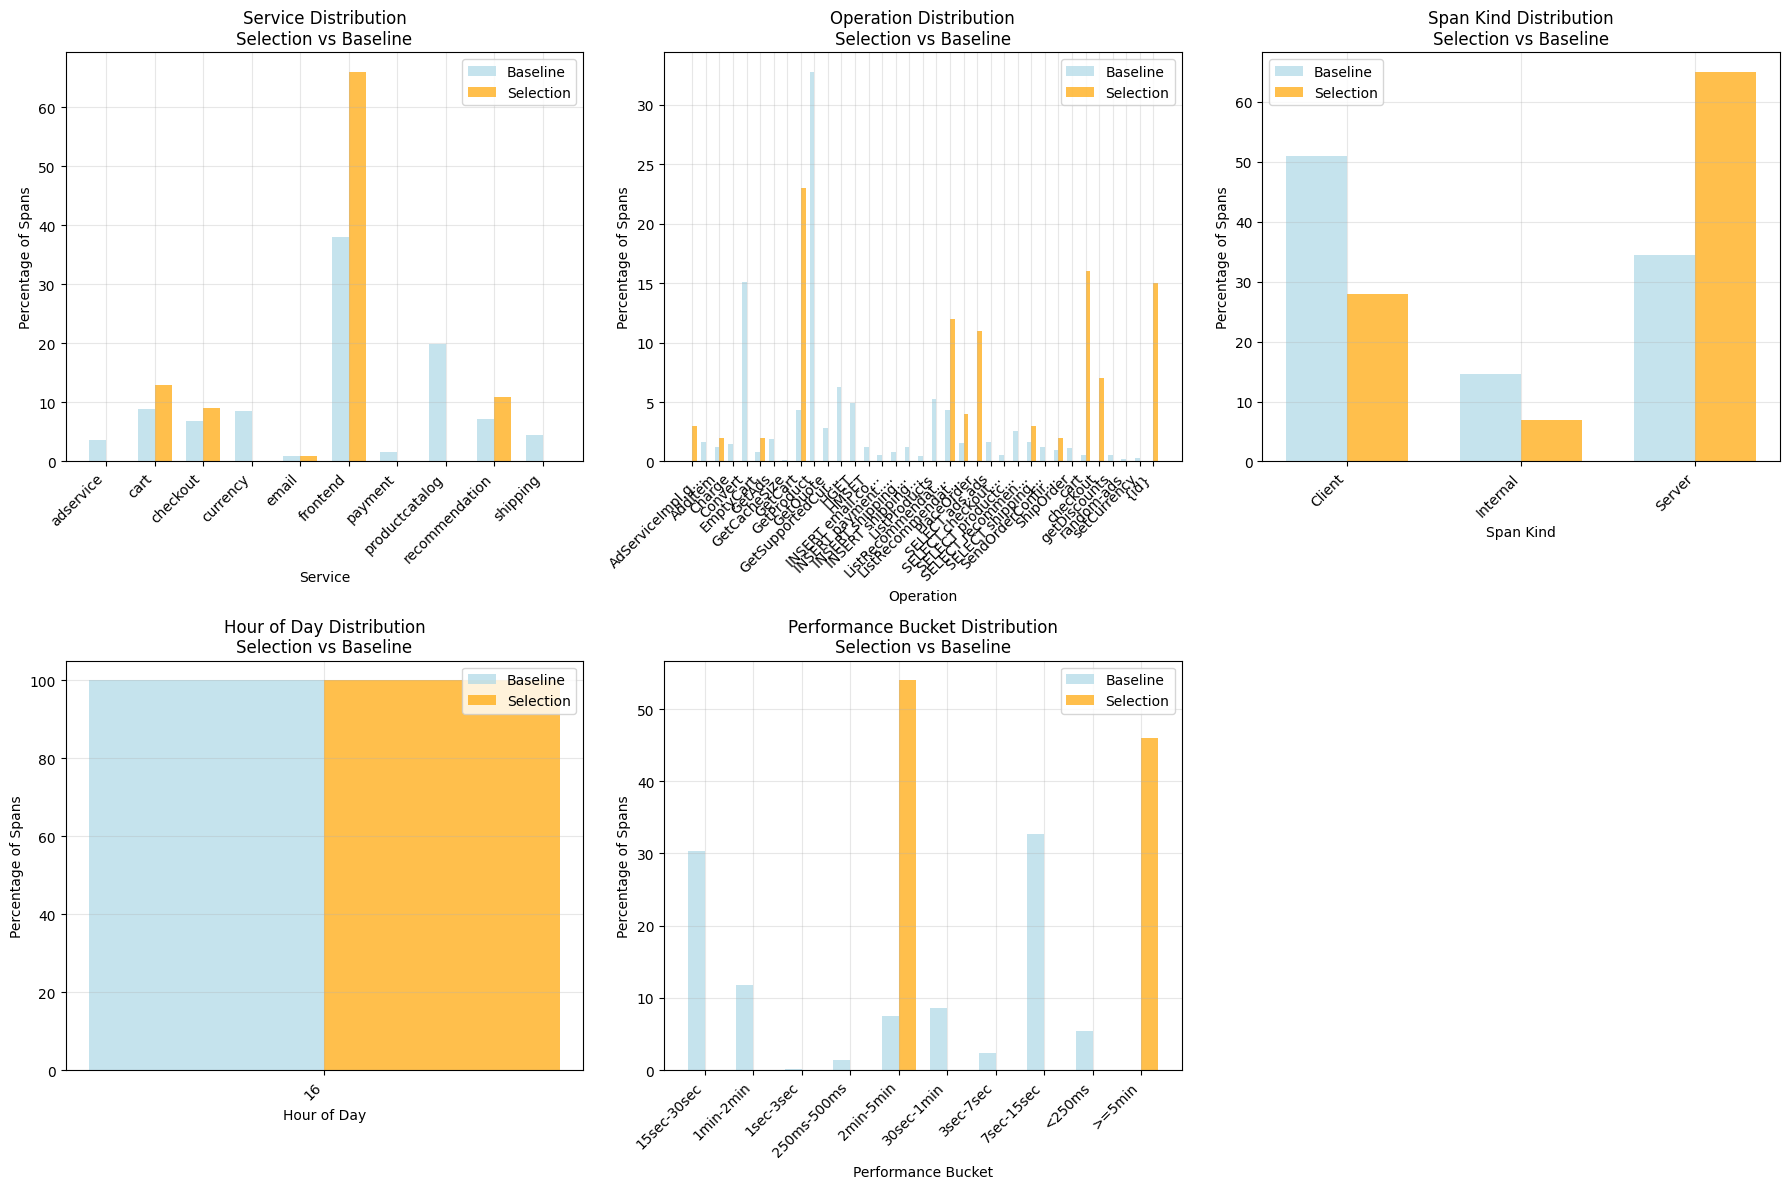


🔍 Key Distinguishing Factors - Very Slow Spans (Top 10%):

Service:
  • frontend: 66.0% in selection vs 38.0% in baseline

Operation:
  • GetCart: 23.0% in selection vs 4.3% in baseline
  • cart: 16.0% in selection vs 0.6% in baseline
  • {id}: 15.0% in selection vs 0.0% in baseline

Span Kind:
  • Server: 65.0% in selection vs 34.4% in baseline

Performance Bucket:
  • 2min-5min: 54.0% in selection vs 7.4% in baseline
  • >=5min: 46.0% in selection vs 0.0% in baseline


In [21]:
class BubbleUpInvestigator:
    """
    A BubbleUp-style investigation tool for trace data analysis
    """
    
    def __init__(self, dataframe):
        self.df = dataframe
        self.investigation_history = []
    
    def investigate_anomaly(self, anomaly_description, selection_mask, show_details=True):
        """
        Start a new investigation of an anomalous region
        """
        print(f"\n{'='*80}")
        print(f"🔍 INVESTIGATING: {anomaly_description}")
        print(f"{'='*80}")
        
        investigation = {
            'description': anomaly_description,
            'selection_mask': selection_mask,
            'selection_size': selection_mask.sum(),
            'baseline_size': (~selection_mask).sum(),
            'distinguishing_factors': self._find_distinguishing_factors(selection_mask)
        }
        
        self.investigation_history.append(investigation)
        
        if show_details:
            self._show_investigation_summary(investigation)
            create_bubbleup_analysis(self.df, selection_mask, f" - {anomaly_description}")
        
        return investigation
    
    def _find_distinguishing_factors(self, selection_mask):
        """
        Find the most distinguishing factors between selection and baseline
        """
        selection_data = self.df[selection_mask]
        baseline_data = self.df[~selection_mask]
        
        distinguishing_factors = []
        
        for dimension in ['service', 'operation', 'Kind', 'PerformanceBucket']:
            if dimension not in self.df.columns:
                continue
                
            # Calculate value distributions
            sel_dist = selection_data[dimension].value_counts(normalize=True)
            base_dist = baseline_data[dimension].value_counts(normalize=True)
            
            for value in sel_dist.index:
                sel_pct = sel_dist.get(value, 0)
                base_pct = base_dist.get(value, 0)
                
                # Calculate enrichment (how much more common in selection vs baseline)
                if base_pct > 0:
                    enrichment = sel_pct / base_pct
                else:
                    enrichment = float('inf') if sel_pct > 0 else 1
                
                if sel_pct > 0.05 and enrichment > 2:  # At least 5% of selection and 2x enriched
                    distinguishing_factors.append({
                        'dimension': dimension,
                        'value': value,
                        'selection_pct': sel_pct * 100,
                        'baseline_pct': base_pct * 100,
                        'enrichment': enrichment,
                        'separation_score': sel_pct - base_pct
                    })
        
        # Sort by separation score (difference in percentages)
        distinguishing_factors.sort(key=lambda x: x['separation_score'], reverse=True)
        
        return distinguishing_factors
    
    def _show_investigation_summary(self, investigation):
        """
        Show a summary of the investigation findings
        """
        print(f"\n📊 Investigation Summary:")
        print(f"   • Selection: {investigation['selection_size']:,} spans")
        print(f"   • Baseline: {investigation['baseline_size']:,} spans")
        print(f"   • Selection represents {investigation['selection_size']/(investigation['selection_size']+investigation['baseline_size'])*100:.1f}% of data")
        
        factors = investigation['distinguishing_factors']
        if factors:
            print(f"\n🎯 Top Distinguishing Factors:")
            for i, factor in enumerate(factors[:5]):
                print(f"   {i+1}. {factor['dimension']} = '{factor['value']}':")
                print(f"      └─ {factor['selection_pct']:.1f}% in selection vs {factor['baseline_pct']:.1f}% in baseline (enrichment: {factor['enrichment']:.1f}x)")
        else:
            print(f"\n⚠️ No strong distinguishing factors found")
    
    def drill_down(self, dimension, value, description=None):
        """
        Drill down into a specific dimension value
        """
        if not self.investigation_history:
            print("No active investigation. Start with investigate_anomaly() first.")
            return
        
        current_selection = self.investigation_history[-1]['selection_mask']
        refined_selection = current_selection & (self.df[dimension] == value)
        
        if refined_selection.sum() < 5:
            print(f"Drill-down would result in too few spans ({refined_selection.sum()}). Aborting.")
            return
        
        drill_description = description or f"Drilling into {dimension} = '{value}'"
        return self.investigate_anomaly(drill_description, refined_selection)
    
    def show_investigation_history(self):
        """
        Show the history of investigations performed
        """
        print(f"\n📋 Investigation History ({len(self.investigation_history)} investigations):")
        for i, inv in enumerate(self.investigation_history):
            print(f"   {i+1}. {inv['description']} - {inv['selection_size']} spans")

# Create the investigator
investigator = BubbleUpInvestigator(df_clean)

# Example investigation workflow
print("🚀 Starting BubbleUp-style Investigation Workflow")

# 1. Investigate overall slow spans
slow_spans = df_clean['duration_seconds'] >= df_clean['duration_seconds'].quantile(0.9)
inv1 = investigator.investigate_anomaly("Very Slow Spans (Top 10%)", slow_spans)


🔬 Following up on top distinguishing factor: PerformanceBucket = '2min-5min'

🔍 INVESTIGATING: Slow spans in PerformanceBucket = '2min-5min'

📊 Investigation Summary:
   • Selection: 54 spans
   • Baseline: 946 spans
   • Selection represents 5.4% of data

🎯 Top Distinguishing Factors:
   1. PerformanceBucket = '2min-5min':
      └─ 100.0% in selection vs 7.1% in baseline (enrichment: 14.1x)
   2. operation = 'GetCart':
      └─ 42.6% in selection vs 4.1% in baseline (enrichment: 10.3x)
   3. operation = 'ListRecommendations':
      └─ 22.2% in selection vs 4.1% in baseline (enrichment: 5.4x)
   4. service = 'cart':
      └─ 24.1% in selection vs 8.5% in baseline (enrichment: 2.8x)
   5. service = 'recommendation':
      └─ 20.4% in selection vs 6.9% in baseline (enrichment: 3.0x)

=== BubbleUp Analysis - Slow spans in PerformanceBucket = '2min-5min' ===
Selection (Anomalous): 54 spans
Baseline (Normal): 946 spans
Selection represents 5.4% of total data


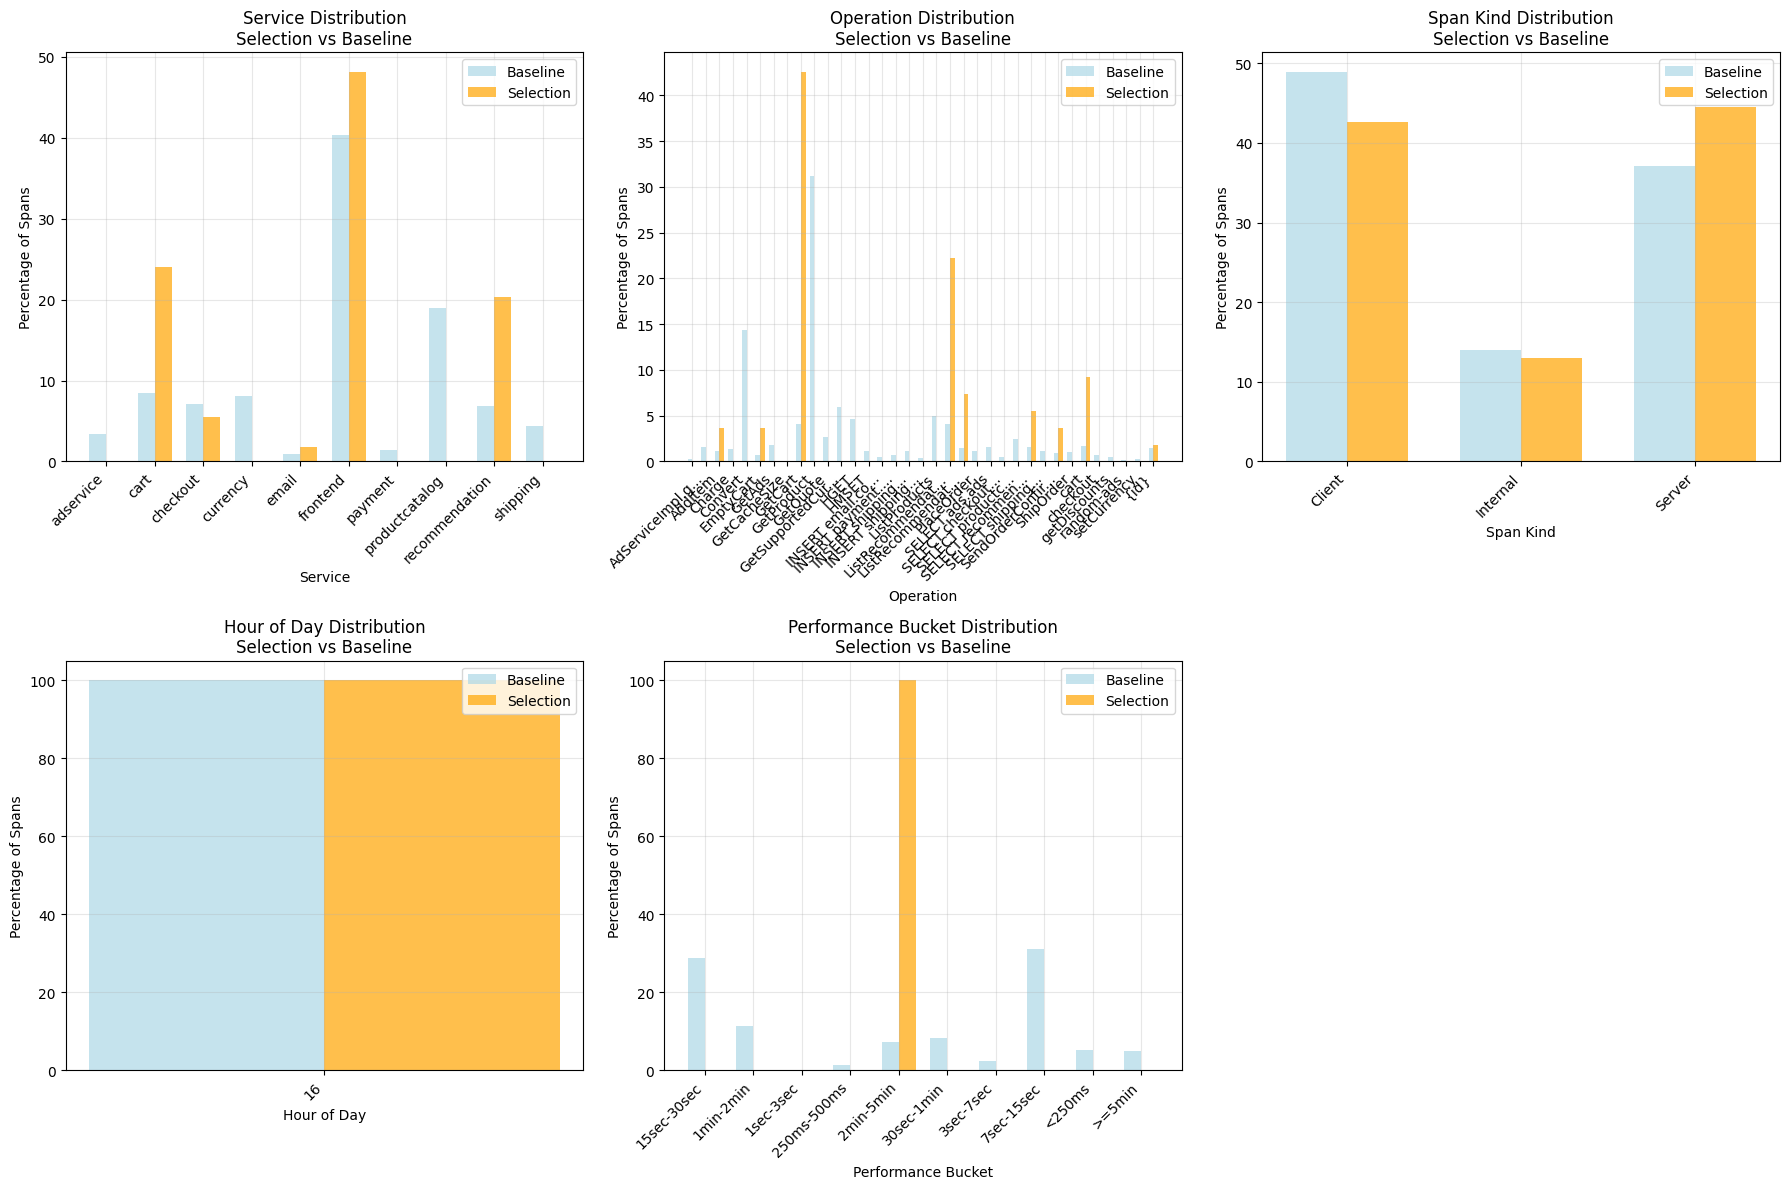


🔍 Key Distinguishing Factors - Slow spans in PerformanceBucket = '2min-5min':

Service:
  • cart: 24.1% in selection vs 8.5% in baseline
  • recommendation: 20.4% in selection vs 6.9% in baseline

Operation:
  • GetCart: 42.6% in selection vs 4.1% in baseline
  • ListRecommendations: 22.2% in selection vs 4.1% in baseline

Performance Bucket:
  • 2min-5min: 100.0% in selection vs 7.1% in baseline

🔬 Further drilling into: PerformanceBucket = '2min-5min'

🔍 INVESTIGATING: Deep dive: PerformanceBucket = '2min-5min'

📊 Investigation Summary:
   • Selection: 54 spans
   • Baseline: 946 spans
   • Selection represents 5.4% of data

🎯 Top Distinguishing Factors:
   1. PerformanceBucket = '2min-5min':
      └─ 100.0% in selection vs 7.1% in baseline (enrichment: 14.1x)
   2. operation = 'GetCart':
      └─ 42.6% in selection vs 4.1% in baseline (enrichment: 10.3x)
   3. operation = 'ListRecommendations':
      └─ 22.2% in selection vs 4.1% in baseline (enrichment: 5.4x)
   4. service = 'cart

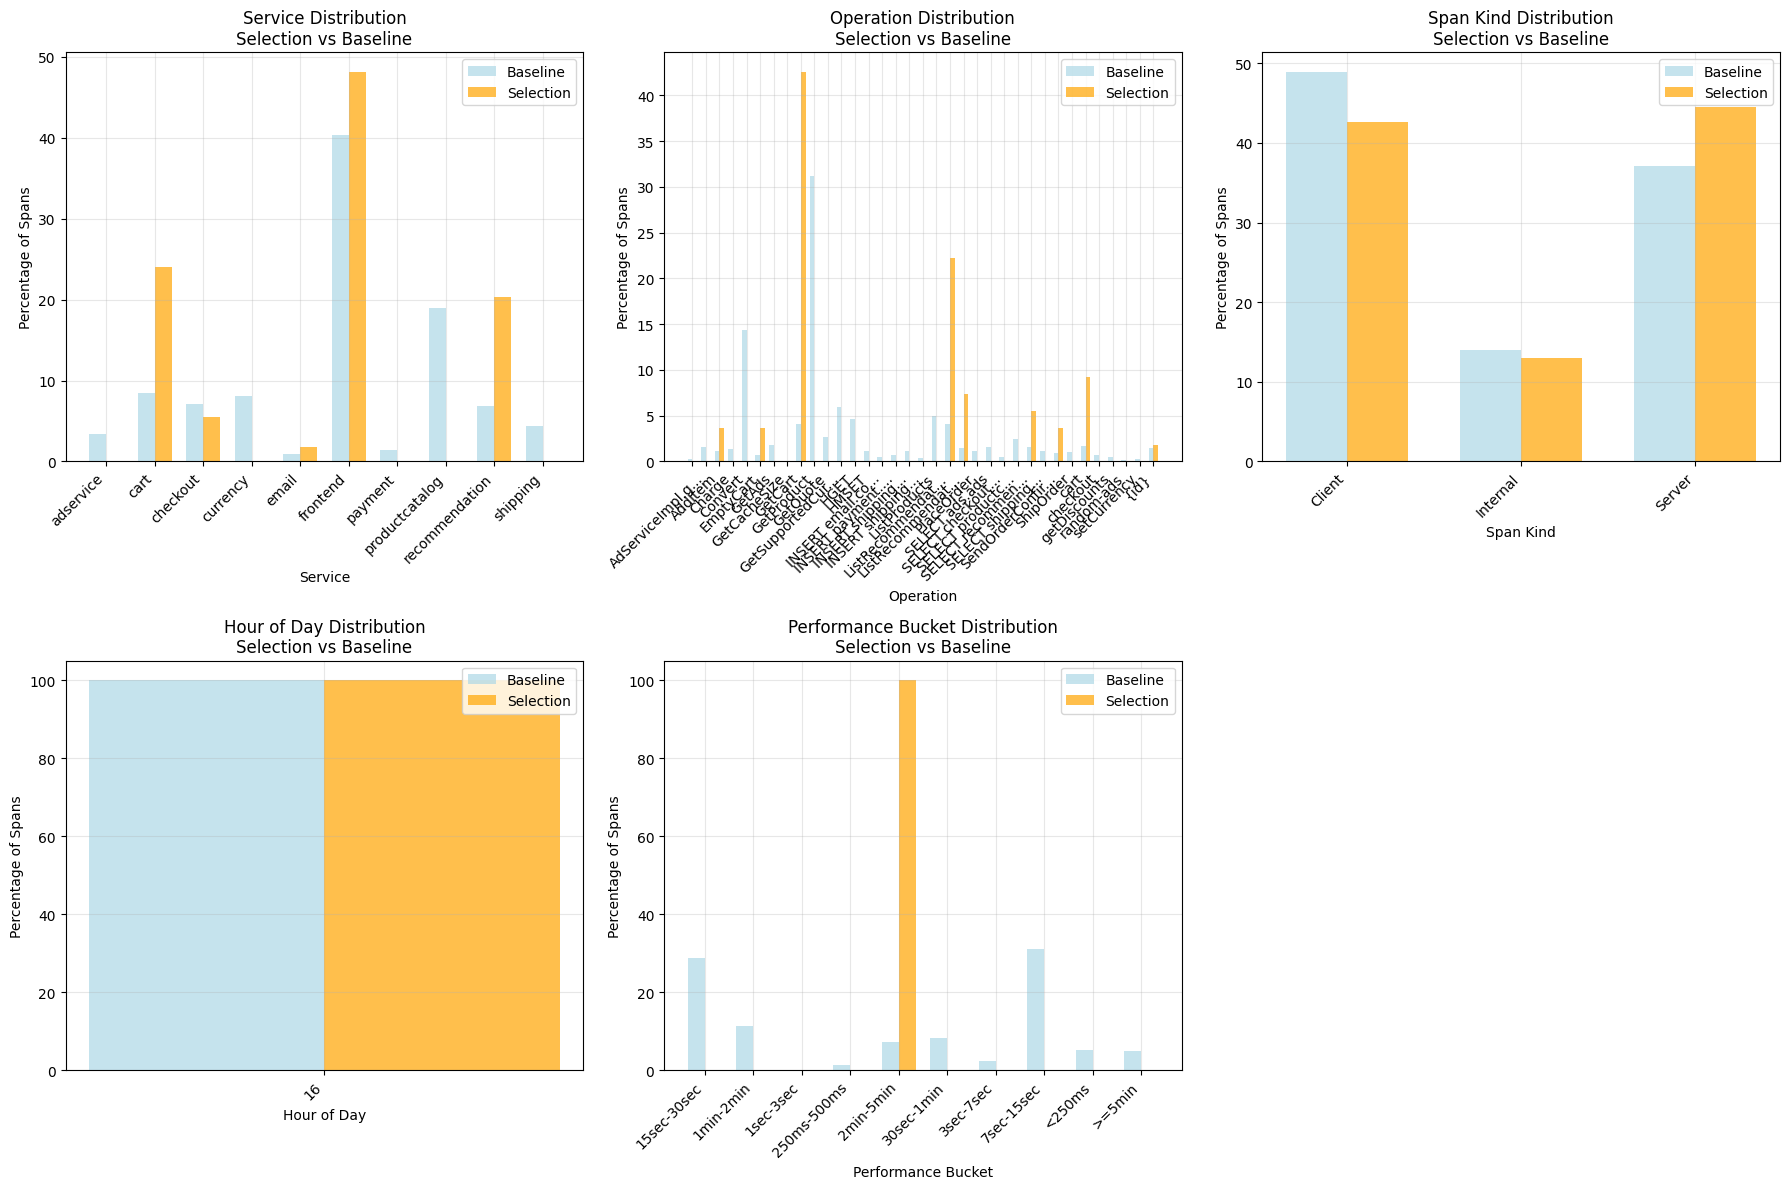


🔍 Key Distinguishing Factors - Deep dive: PerformanceBucket = '2min-5min':

Service:
  • cart: 24.1% in selection vs 8.5% in baseline
  • recommendation: 20.4% in selection vs 6.9% in baseline

Operation:
  • GetCart: 42.6% in selection vs 4.1% in baseline
  • ListRecommendations: 22.2% in selection vs 4.1% in baseline

Performance Bucket:
  • 2min-5min: 100.0% in selection vs 7.1% in baseline

📋 Investigation History (3 investigations):
   1. Very Slow Spans (Top 10%) - 100 spans
   2. Slow spans in PerformanceBucket = '2min-5min' - 54 spans
   3. Deep dive: PerformanceBucket = '2min-5min' - 54 spans


In [22]:
# 2. Follow up with the most distinguishing factor from the first investigation
if inv1['distinguishing_factors']:
    top_factor = inv1['distinguishing_factors'][0]
    print(f"\n🔬 Following up on top distinguishing factor: {top_factor['dimension']} = '{top_factor['value']}'")
    
    inv2 = investigator.drill_down(
        top_factor['dimension'], 
        top_factor['value'],
        f"Slow spans in {top_factor['dimension']} = '{top_factor['value']}'"
    )
    
    # 3. Continue drilling down if there are more factors
    if inv2 and inv2['distinguishing_factors']:
        next_factor = inv2['distinguishing_factors'][0]
        print(f"\n🔬 Further drilling into: {next_factor['dimension']} = '{next_factor['value']}'")
        
        inv3 = investigator.drill_down(
            next_factor['dimension'], 
            next_factor['value'],
            f"Deep dive: {next_factor['dimension']} = '{next_factor['value']}'"
        )

# Show the investigation trail
investigator.show_investigation_history()

## 10. Usage Guide for BubbleUp-style Analysis

This section provides instructions for using the BubbleUp-inspired tools to investigate anomalies in your trace data.


🔍 BUBBLEUP-STYLE INVESTIGATION GUIDE

This notebook now includes BubbleUp-inspired functionality to investigate anomalies in your trace data.
Here's how to use the tools:

1. BASIC ANOMALY ANALYSIS
   ----------------------
   Use create_bubbleup_analysis() to compare any selection vs. baseline:
   
   # Example: Investigate slow spans
   slow_mask = df_clean['duration_seconds'] > df_clean['duration_seconds'].quantile(0.9)
   create_bubbleup_analysis(df_clean, slow_mask, " - Slow Spans Investigation")

2. HEATMAP REGION ANALYSIS
   ----------------------
   Use analyze_heatmap_region() to investigate specific areas of the heatmap:
   
   # Example: Investigate specific service-operation combinations
   analyze_heatmap_region(
       service_list=['frontend', 'checkout'], 
       operation_list=['PlaceOrder'],
       duration_min=100
   )

3. AUTOMATED ANOMALY DETECTION
   -------------------------
   Use detect_and_analyze_anomalies() to automatically find and analyze anomalies

4. IT

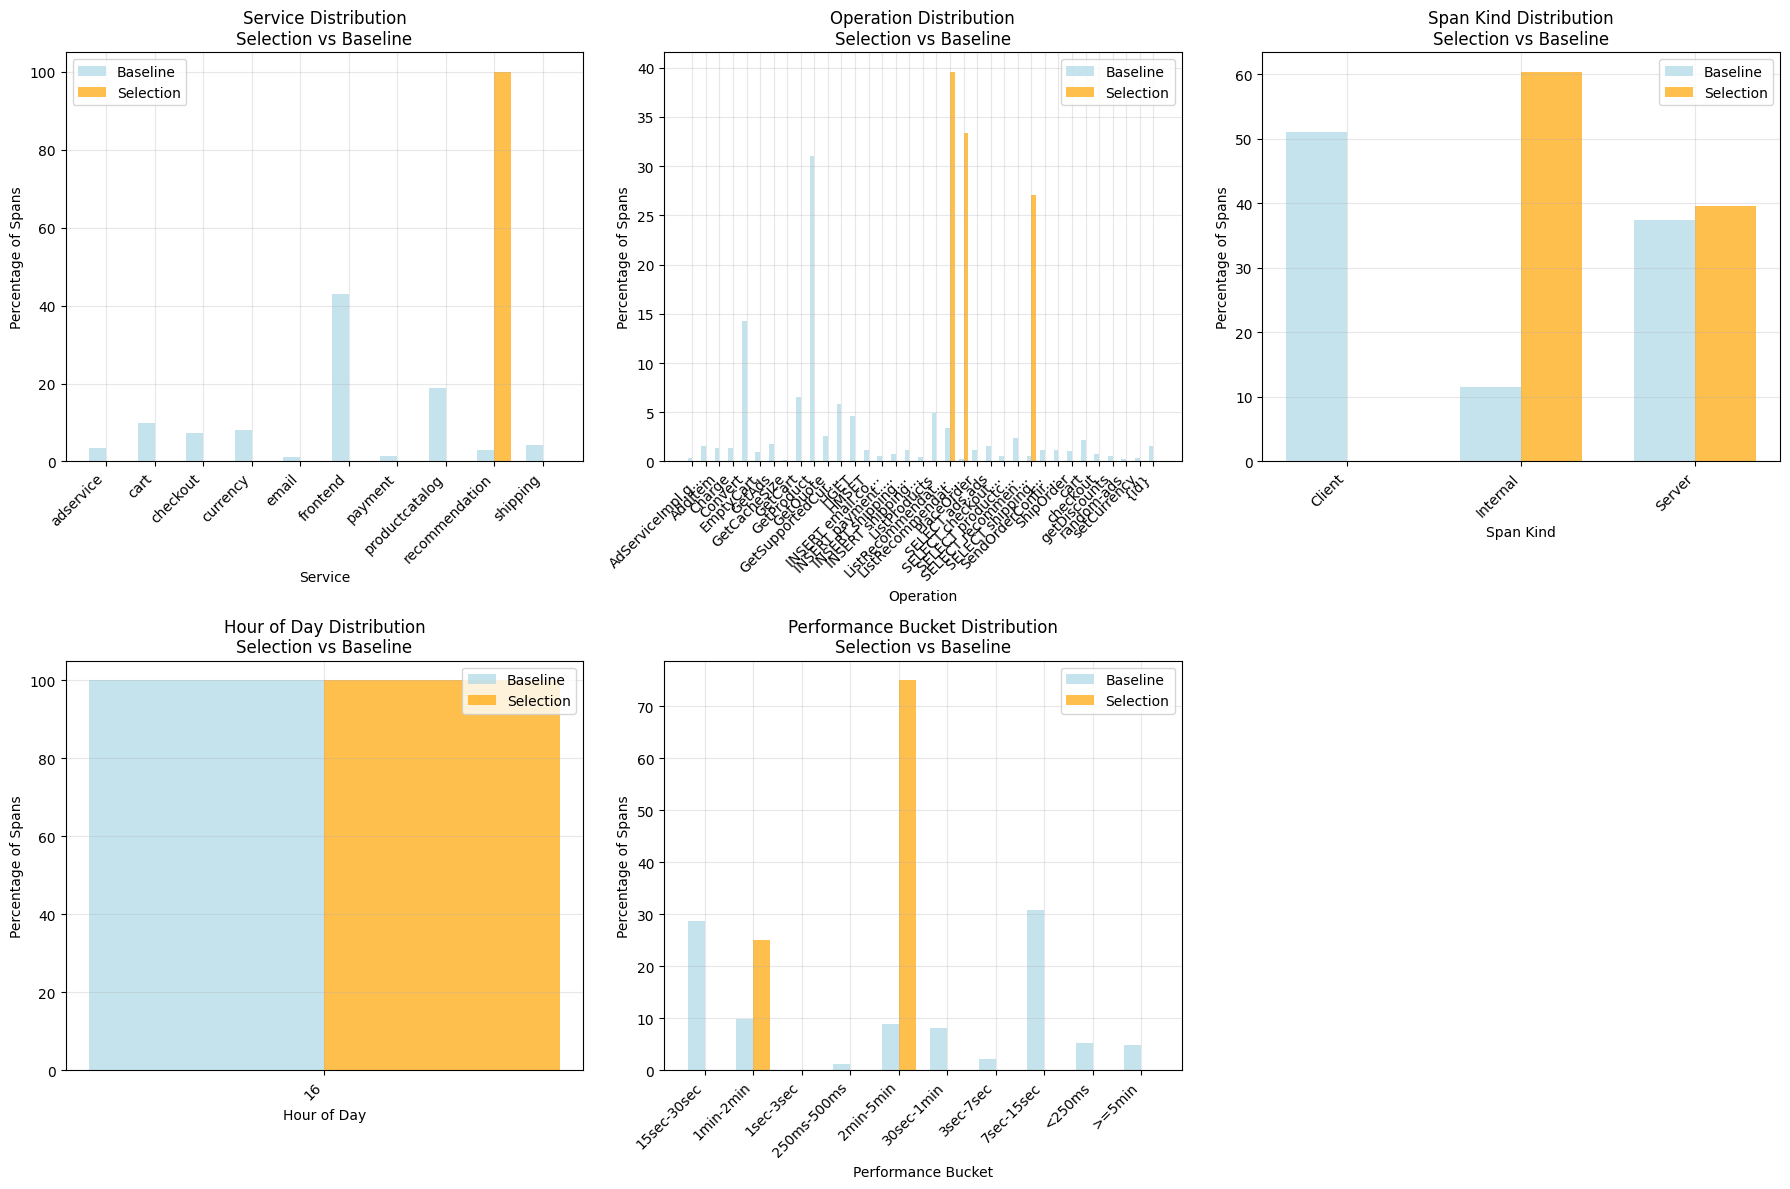


🔍 Key Distinguishing Factors - Slow Recommendation Example:

Service:
  • recommendation: 100.0% in selection vs 2.9% in baseline

Operation:
  • ListRecommendations: 39.6% in selection vs 3.4% in baseline
  • ListRecommendationsFunction: 33.3% in selection vs 0.2% in baseline
  • SELECT recommendation.products: 27.1% in selection vs 0.5% in baseline

Span Kind:
  • Internal: 60.4% in selection vs 11.6% in baseline

Performance Bucket:
  • 2min-5min: 75.0% in selection vs 8.9% in baseline
  • 1min-2min: 25.0% in selection vs 9.9% in baseline

✅ BubbleUp-style analysis tools are ready to use!
   Investigate anomalies to understand what makes them different from normal operations.


In [23]:
print("""
🔍 BUBBLEUP-STYLE INVESTIGATION GUIDE
=====================================

This notebook now includes BubbleUp-inspired functionality to investigate anomalies in your trace data.
Here's how to use the tools:

1. BASIC ANOMALY ANALYSIS
   ----------------------
   Use create_bubbleup_analysis() to compare any selection vs. baseline:
   
   # Example: Investigate slow spans
   slow_mask = df_clean['duration_seconds'] > df_clean['duration_seconds'].quantile(0.9)
   create_bubbleup_analysis(df_clean, slow_mask, " - Slow Spans Investigation")

2. HEATMAP REGION ANALYSIS
   ----------------------
   Use analyze_heatmap_region() to investigate specific areas of the heatmap:
   
   # Example: Investigate specific service-operation combinations
   analyze_heatmap_region(
       service_list=['frontend', 'checkout'], 
       operation_list=['PlaceOrder'],
       duration_min=100
   )

3. AUTOMATED ANOMALY DETECTION
   -------------------------
   Use detect_and_analyze_anomalies() to automatically find and analyze anomalies

4. ITERATIVE INVESTIGATION
   ----------------------
   Use BubbleUpInvestigator class for guided investigation:
   
   investigator = BubbleUpInvestigator(df_clean)
   
   # Start investigation
   slow_spans = df_clean['duration_seconds'] > threshold
   inv = investigator.investigate_anomaly("Slow Spans", slow_spans)
   
   # Drill down into distinguishing factors
   investigator.drill_down('service', 'frontend', "Frontend Issues")

5. UNDERSTANDING THE OUTPUT
   -----------------------
   • Paired histograms show distribution differences between selection and baseline
   • Orange bars = your selection (anomalous data)
   • Blue bars = baseline (normal data)
   • Look for bars where orange is much higher than blue
   • Distinguishing factors list shows the most important differences

6. INVESTIGATION WORKFLOW
   ---------------------
   1. Start with an anomaly (slow requests, errors, etc.)
   2. Use BubbleUp analysis to see what makes it different
   3. Drill down into the most distinguishing factor
   4. Repeat until you find the root cause

💡 TIP: Just like in the BubbleUp paper, focus on dimensions where the selection
   shows a clear concentration in specific values that are absent/rare in baseline.
""")

# Quick example for new users
print("\n" + "="*60)
print("QUICK EXAMPLE - Try this to get started:")
print("="*60)

# Find an interesting anomaly to investigate
recommendation_slow = (df_clean['service'] == 'recommendation') & (df_clean['duration_seconds'] > 100)

if recommendation_slow.sum() > 0:
    print(f"\nFound {recommendation_slow.sum()} slow recommendation service spans to investigate...")
    create_bubbleup_analysis(df_clean, recommendation_slow, " - Slow Recommendation Example")
else:
    print("\nNo slow recommendation spans found. Try investigating a different anomaly:")
    print("Example alternatives:")
    print("- Very slow spans: df_clean['duration_seconds'] > df_clean['duration_seconds'].quantile(0.95)")
    print("- Frontend errors: df_clean['service'] == 'frontend' & df_clean['StatusCode'] != '200'")
    print("- Server spans: df_clean['Kind'] == 'Server'")

print(f"\n✅ BubbleUp-style analysis tools are ready to use!")
print(f"   Investigate anomalies to understand what makes them different from normal operations.")

In [25]:
# Check available attributes/columns in the CSV data
print("Available columns in the dataset:")
print(df_clean.columns.tolist())
print(f"\nDataset shape: {df_clean.shape}")
print(f"\nSample of the data:")
print(df_clean.head())

Available columns in the dataset:
['TenantId', 'TimeGenerated [UTC]', 'Name', 'SpanId', 'ParentSpanId', 'TraceId', 'TraceState', 'Kind', 'EndTime [UTC]', 'StatusMessage', 'StatusCode', 'Links', 'ScopeName', 'ScopeVersion', 'ResourceAttributes', 'DroppedAttributesCount', 'DroppedEventsCount', 'DroppedLinksCount', 'Attributes', 'ServiceNamespace', 'ServiceName', 'ServiceVersion', 'ServiceInstanceId', 'RoleName', 'SDKVersion', 'EndUserId', 'ResourceAttributesId', 'DurationMs', 'ResultCode', 'UserId', 'UserAccountId', 'SessionId', 'ClientBrowser', 'ClientOS', 'ClientModel', 'ClientType', 'ClientIP', 'ClientCity', 'ClientStateOrProvince', 'ClientCountryOrRegion', 'Measurements', 'SyntheticSource', 'Source', 'Target', 'EnrichedName', 'OperationName', 'Success', 'DependencyType', 'Data', 'ItemCount', 'PerformanceBucket', 'SourceSystem', 'Type', '_ResourceId', 'timestamp', 'duration_seconds', 'operation', 'service', 'hour', 'minute', 'time_bucket']

Dataset shape: (1000, 61)

Sample of the dat

In [26]:
# Get key attributes for analysis
categorical_columns = []
numerical_columns = []

for col in df_clean.columns:
    if df_clean[col].dtype == 'object' or df_clean[col].dtype.name == 'category':
        categorical_columns.append(col)
    elif df_clean[col].dtype in ['int64', 'float64']:
        numerical_columns.append(col)

print("Categorical attributes:")
for col in categorical_columns:
    unique_vals = df_clean[col].nunique()
    print(f"  {col}: {unique_vals} unique values")
    
print(f"\nNumerical attributes:")
for col in numerical_columns:
    print(f"  {col}: {df_clean[col].dtype}")

# Focus on key attributes for BubbleUp analysis
key_attributes = ['service', 'operation', 'span_kind', 'PerformanceBucket']
print(f"\nKey attributes for comparison: {key_attributes}")

Categorical attributes:
  TenantId: 1 unique values
  TimeGenerated [UTC]: 663 unique values
  Name: 41 unique values
  SpanId: 1000 unique values
  ParentSpanId: 546 unique values
  TraceId: 85 unique values
  Kind: 3 unique values
  EndTime [UTC]: 643 unique values
  StatusMessage: 4 unique values
  StatusCode: 1 unique values
  Links: 1 unique values
  ScopeName: 9 unique values
  ScopeVersion: 6 unique values
  Attributes: 135 unique values
  ServiceName: 10 unique values
  ServiceInstanceId: 2 unique values
  RoleName: 10 unique values
  SDKVersion: 3 unique values
  ResourceAttributesId: 44 unique values
  ClientBrowser: 3 unique values
  ClientType: 1 unique values
  ClientIP: 1 unique values
  Measurements: 1 unique values
  Target: 18 unique values
  EnrichedName: 43 unique values
  DependencyType: 3 unique values
  Data: 29 unique values
  PerformanceBucket: 10 unique values
  Type: 1 unique values
  _ResourceId: 1 unique values
  operation: 35 unique values
  service: 10 uni

## Comprehensive Attribute Analysis: Baseline vs Selection

In [27]:
def analyze_all_attributes(df, selection_mask, title_suffix="", max_categories=10):
    """
    Generate comprehensive baseline vs selection comparison for all attributes.
    
    Parameters:
    - df: DataFrame with the data
    - selection_mask: Boolean mask for the selection (anomalous data)
    - title_suffix: Additional text for plot titles
    - max_categories: Maximum number of categories to show for categorical variables
    """
    
    selection_data = df[selection_mask]
    baseline_data = df[~selection_mask]
    
    print(f"📊 COMPREHENSIVE ATTRIBUTE ANALYSIS{title_suffix}")
    print("=" * 60)
    print(f"Selection: {len(selection_data)} spans ({len(selection_data)/len(df)*100:.1f}%)")
    print(f"Baseline: {len(baseline_data)} spans ({len(baseline_data)/len(df)*100:.1f}%)")
    print()
    
    # Get all categorical and numerical columns
    categorical_cols = []
    numerical_cols = []
    
    for col in df.columns:
        if col in ['duration_seconds', 'trace_id', 'span_id', 'parent_span_id']:
            continue  # Skip these columns
        elif df[col].dtype == 'object' or df[col].dtype.name == 'category':
            categorical_cols.append(col)
        elif df[col].dtype in ['int64', 'float64']:
            numerical_cols.append(col)
    
    # Remove columns with too many unique values for categorical analysis
    categorical_cols = [col for col in categorical_cols if df[col].nunique() <= 50]
    
    # Calculate grid size for subplots
    total_plots = len(categorical_cols) + len(numerical_cols)
    if total_plots == 0:
        print("No suitable attributes found for analysis.")
        return
    
    cols = min(3, total_plots)
    rows = (total_plots + cols - 1) // cols
    
    fig, axes = plt.subplots(rows, cols, figsize=(6*cols, 5*rows))
    if total_plots == 1:
        axes = [axes]
    elif rows == 1:
        axes = axes.reshape(1, -1)
    
    plot_idx = 0
    
    # Plot categorical attributes
    for col in categorical_cols:
        if plot_idx >= total_plots:
            break
            
        ax = axes[plot_idx // cols, plot_idx % cols] if rows > 1 else axes[plot_idx]
        
        # Calculate percentages for both groups
        selection_counts = selection_data[col].value_counts()
        baseline_counts = baseline_data[col].value_counts()
        
        # Get top categories to avoid overcrowding
        all_categories = list(set(selection_counts.index.tolist() + baseline_counts.index.tolist()))
        if len(all_categories) > max_categories:
            # Get top categories by total frequency
            total_counts = df[col].value_counts()
            all_categories = total_counts.head(max_categories).index.tolist()
        
        # Calculate percentages
        selection_pct = [(selection_counts.get(cat, 0) / len(selection_data) * 100) if len(selection_data) > 0 else 0 
                        for cat in all_categories]
        baseline_pct = [(baseline_counts.get(cat, 0) / len(baseline_data) * 100) if len(baseline_data) > 0 else 0 
                       for cat in all_categories]
        
        # Create bar plot
        x = np.arange(len(all_categories))
        width = 0.35
        
        ax.bar(x - width/2, baseline_pct, width, label='Baseline', alpha=0.7, color='lightblue')
        ax.bar(x + width/2, selection_pct, width, label='Selection', alpha=0.8, color='orange')
        
        ax.set_xlabel(col.replace('_', ' ').title())
        ax.set_ylabel('Percentage of Spans')
        ax.set_title(f'{col.replace("_", " ").title()}\nDistribution Comparison')
        ax.set_xticks(x)
        ax.set_xticklabels(all_categories, rotation=45, ha='right')
        ax.legend()
        ax.grid(True, alpha=0.3)
        
        plot_idx += 1
    
    # Plot numerical attributes
    for col in numerical_cols:
        if plot_idx >= total_plots:
            break
            
        ax = axes[plot_idx // cols, plot_idx % cols] if rows > 1 else axes[plot_idx]
        
        # Create histograms
        if len(selection_data) > 0:
            ax.hist(selection_data[col].dropna(), bins=20, alpha=0.7, label='Selection', 
                   color='orange', density=True)
        if len(baseline_data) > 0:
            ax.hist(baseline_data[col].dropna(), bins=20, alpha=0.5, label='Baseline', 
                   color='lightblue', density=True)
        
        ax.set_xlabel(col.replace('_', ' ').title())
        ax.set_ylabel('Density')
        ax.set_title(f'{col.replace("_", " ").title()}\nDistribution Comparison')
        ax.legend()
        ax.grid(True, alpha=0.3)
        
        plot_idx += 1
    
    # Hide empty subplots
    for i in range(plot_idx, rows * cols):
        if rows > 1:
            axes[i // cols, i % cols].set_visible(False)
        else:
            if i < len(axes):
                axes[i].set_visible(False)
    
    plt.tight_layout()
    plt.show()
    
    # Print key insights
    print("\n🔍 KEY INSIGHTS:")
    print("-" * 40)
    
    for col in categorical_cols:
        if len(selection_data) == 0:
            continue
            
        selection_dist = selection_data[col].value_counts(normalize=True) * 100
        baseline_dist = baseline_data[col].value_counts(normalize=True) * 100 if len(baseline_data) > 0 else pd.Series()
        
        # Find the most distinguishing values
        max_diff = 0
        top_value = None
        
        for value in selection_dist.index:
            sel_pct = selection_dist[value]
            base_pct = baseline_dist.get(value, 0)
            diff = sel_pct - base_pct
            if diff > max_diff:
                max_diff = diff
                top_value = value
        
        if top_value is not None and max_diff > 5:  # Only show if difference > 5%
            sel_pct = selection_dist[top_value]
            base_pct = baseline_dist.get(top_value, 0)
            print(f"  {col}: '{top_value}' appears in {sel_pct:.1f}% of selection vs {base_pct:.1f}% of baseline")

print("Function defined successfully!")

Function defined successfully!


Analyzing very slow spans (>= 240.71s)
📊 COMPREHENSIVE ATTRIBUTE ANALYSIS - Very Slow Spans (Top 5%)
Selection: 50 spans (5.0%)
Baseline: 950 spans (95.0%)



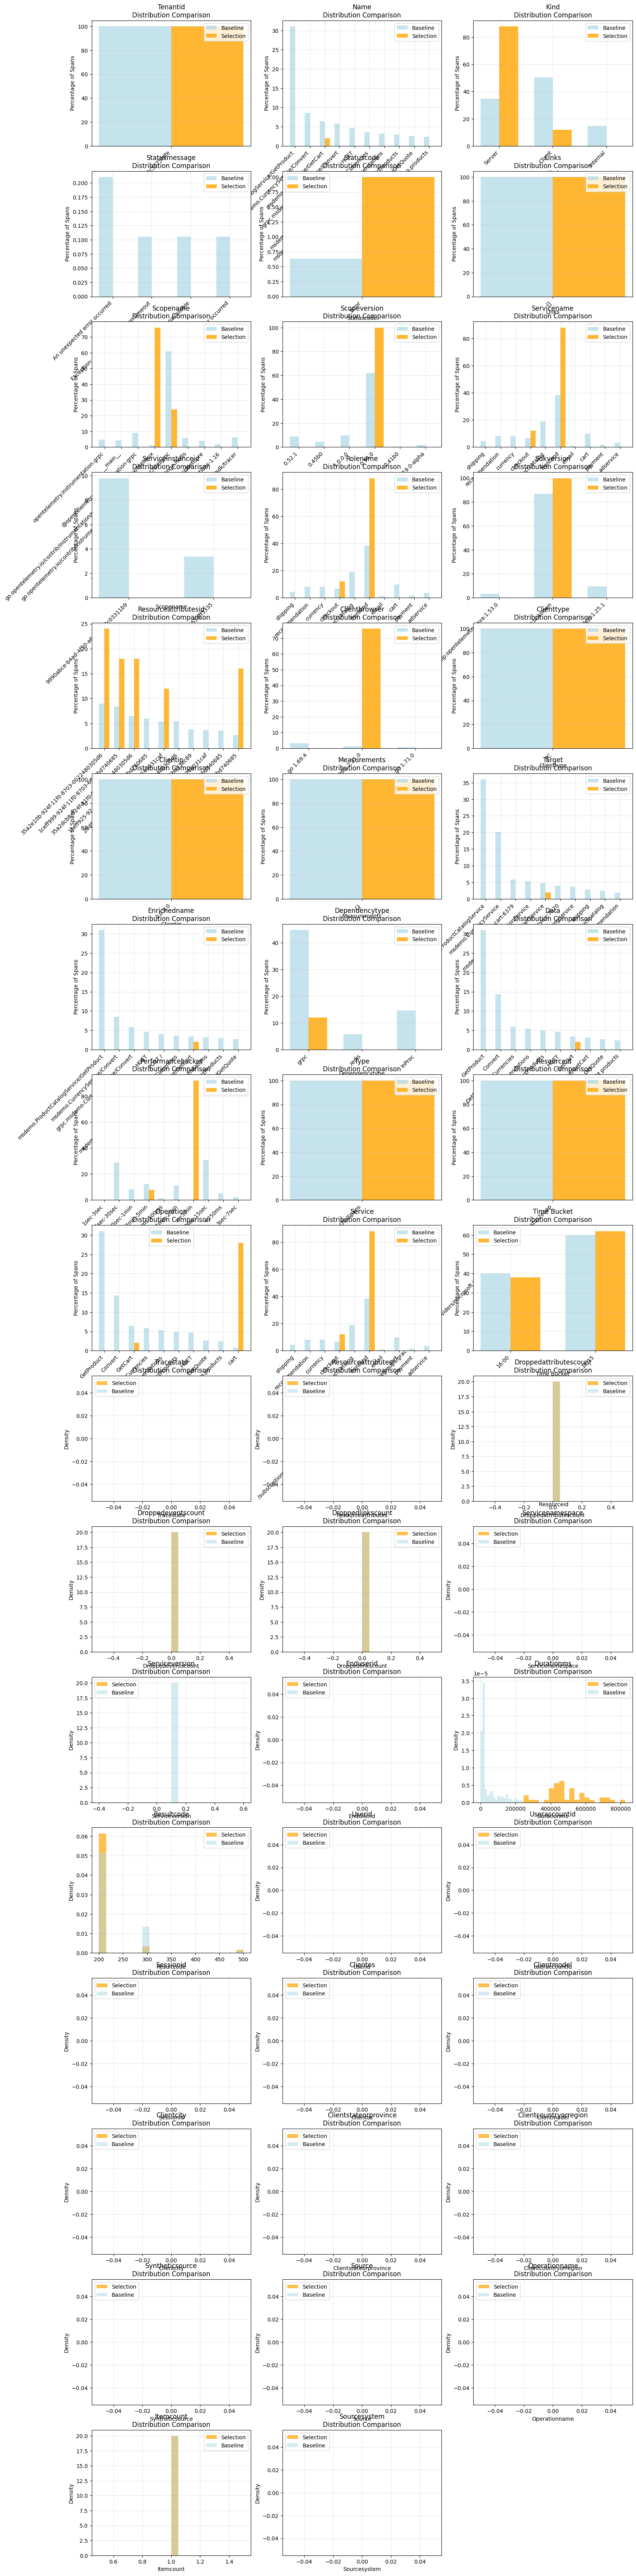


🔍 KEY INSIGHTS:
----------------------------------------
  Name: '/product/{id}' appears in 28.0% of selection vs 0.1% of baseline
  Kind: 'Server' appears in 88.0% of selection vs 34.8% of baseline
  ScopeName: 'go.opentelemetry.io/contrib/instrumentation/github.com/gorilla/mux/otelmux' appears in 76.0% of selection vs 1.2% of baseline
  ScopeVersion: '0.54.0' appears in 100.0% of selection vs 71.1% of baseline
  ServiceName: 'frontend' appears in 88.0% of selection vs 38.3% of baseline
  RoleName: 'frontend' appears in 88.0% of selection vs 38.3% of baseline
  SDKVersion: 'otlp:unknown:unknown:unknown' appears in 100.0% of selection vs 87.1% of baseline
  ResourceAttributesId: '35a2e10b-924f-11f0-8703-0022480305d6' appears in 24.0% of selection vs 9.1% of baseline
  ClientBrowser: 'requests 2.31.0' appears in 100.0% of selection vs 22.4% of baseline
  Target: 'msdemo.CheckoutService' appears in 91.7% of selection vs 0.1% of baseline
  EnrichedName: 'GET /product/{id}' appears in 28.

In [28]:
# Example 1: Analyze very slow spans (top 5%) across all attributes
very_slow_threshold = df_clean['duration_seconds'].quantile(0.95)
very_slow_mask = df_clean['duration_seconds'] >= very_slow_threshold

print(f"Analyzing very slow spans (>= {very_slow_threshold:.2f}s)")
analyze_all_attributes(df_clean, very_slow_mask, " - Very Slow Spans (Top 5%)")

Analyzing frontend service performance anomalies...
📊 COMPREHENSIVE ATTRIBUTE ANALYSIS - Frontend Service Anomalies
Selection: 99 spans (9.9%)
Baseline: 901 spans (90.1%)



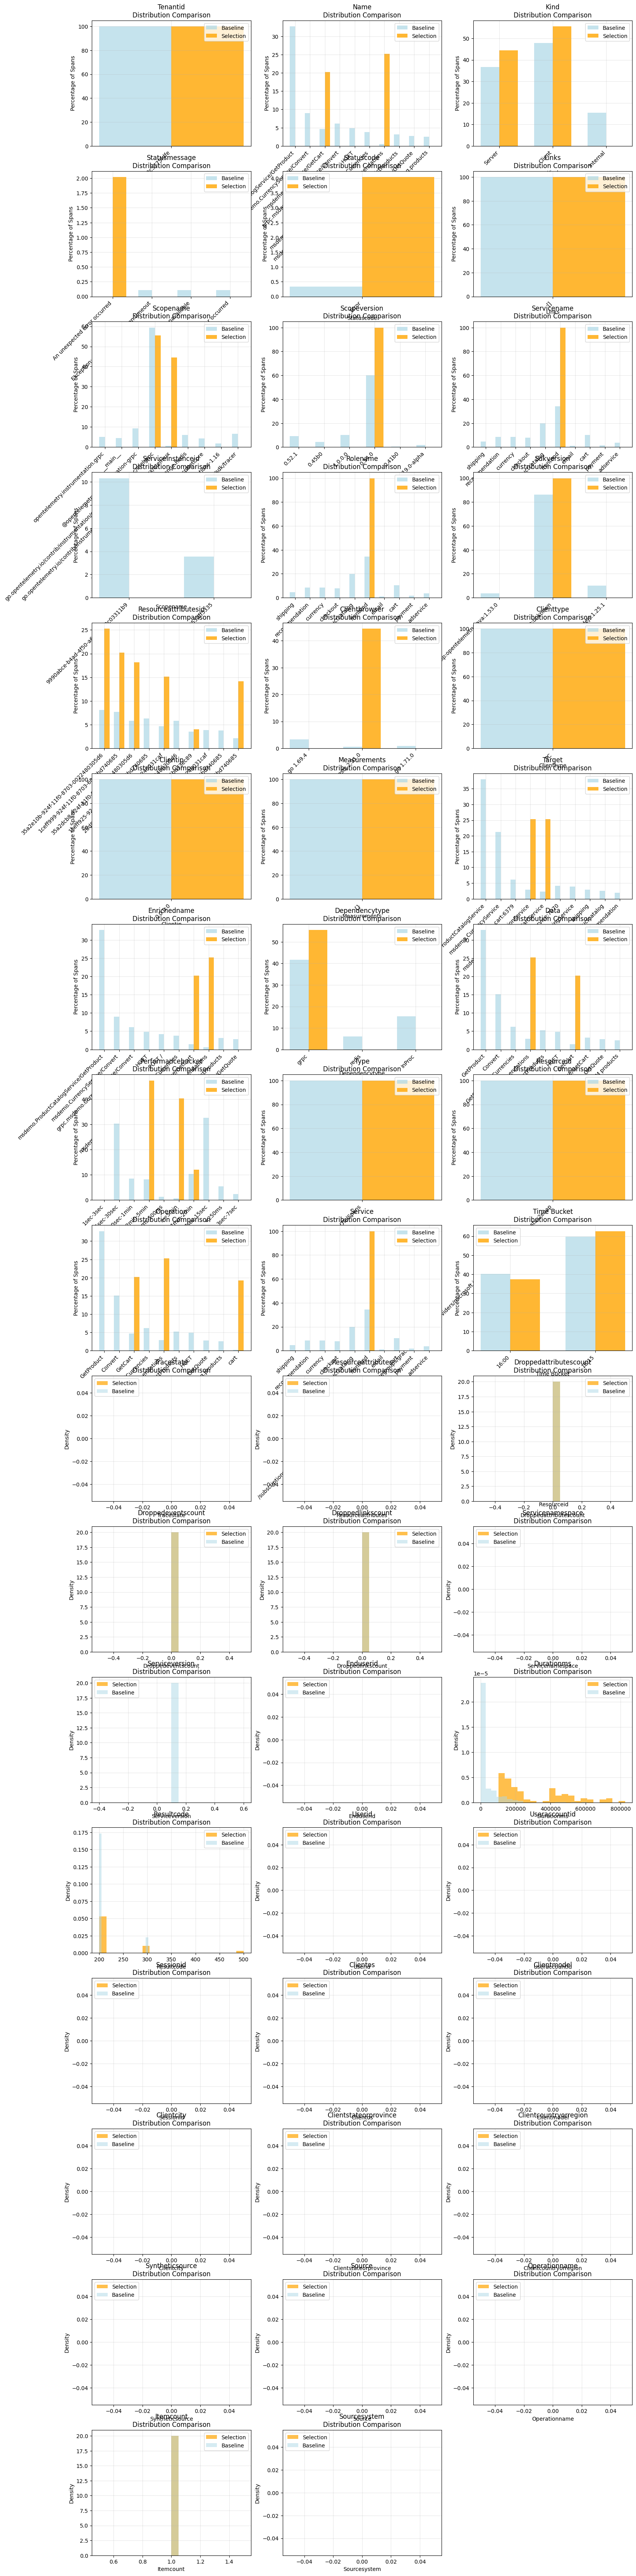


🔍 KEY INSIGHTS:
----------------------------------------
  Name: 'msdemo.RecommendationService/ListRecommendations' appears in 25.3% of selection vs 0.6% of baseline
  Kind: 'Client' appears in 55.6% of selection vs 47.8% of baseline
  StatusMessage: 'An unexpected error occurred' appears in 100.0% of selection vs 0.0% of baseline
  ScopeName: 'go.opentelemetry.io/contrib/instrumentation/github.com/gorilla/mux/otelmux' appears in 44.4% of selection vs 0.6% of baseline
  ScopeVersion: '0.54.0' appears in 100.0% of selection vs 69.3% of baseline
  ServiceName: 'frontend' appears in 100.0% of selection vs 34.3% of baseline
  RoleName: 'frontend' appears in 100.0% of selection vs 34.3% of baseline
  SDKVersion: 'otlp:unknown:unknown:unknown' appears in 100.0% of selection vs 86.3% of baseline
  ResourceAttributesId: '35a2e10b-924f-11f0-8703-0022480305d6' appears in 25.3% of selection vs 8.1% of baseline
  ClientBrowser: 'requests 2.31.0' appears in 100.0% of selection vs 11.6% of baseline

In [29]:
# Example 2: Analyze frontend service anomalies across all attributes  
frontend_mask = (df_clean['service'] == 'frontend') & (df_clean['duration_seconds'] > df_clean['duration_seconds'].quantile(0.8))

print(f"Analyzing frontend service performance anomalies...")
analyze_all_attributes(df_clean, frontend_mask, " - Frontend Service Anomalies")